# Donor Reactivation (DSC) — Predictive Targeting & Business Case

**Goal:** Predict which inactive donors are likely to donate **€30+** and prove the model outperforms random targeting.  
**Business constraint:** Mailing cost is **€0.80 per letter**.  
**Deliverable:** A ranked donor list and an optimal contact strategy that maximizes profit.

> This project was developed as part of a group assignment.  
> **My contributions:** feature engineering, model training/tuning, evaluation (AUC, lift/gains), and business case analysis.


In [247]:
import pandas as pd
import numpy as np

## Reproducibility

All datasets are included in the repository under `data/raw/`.  
This notebook uses **relative paths** so it can be run from the GitHub repository without editing file locations.


In [ ]:
campaign_6169 = pd.read_csv("../data/raw/selection_campaign_6169.csv", sep=",")
campaign_7244 = pd.read_csv("../data/raw/selection_campaign_7244.csv", sep=",")

gifts = pd.read_csv("../data/raw/gifts.csv", sep=",")
donors = pd.read_csv("../data/raw/donors.csv", sep=",")
campaigns = pd.read_csv("../data/raw/campaigns.csv", sep=";")



# **Step 1: Cleaning the data**

## Timeline Rationale: Why We Extended the Independent Window to 5 Years

In the initial version of the project, we followed the classic WWF/UNICEF modeling guidelines and used a **3-year Independent Window (IW)** to compute donor features. This approach is appropriate for active donors who give regularly.  
However, our context is different: **campaign 6169 is a reactivation campaign**, meaning the target group consists of donors who have been inactive for long periods and whose donation patterns are sparse and irregular.

Because these donors give infrequently, a 3-year window failed to capture enough behavioral history to build meaningful features—many donors appeared with *no donations at all* in the IW, which created very weak predictive signals.  
To address this, we expanded the IW to **5 years**, which allowed us to capture:

- More complete donation histories  
- Long-term behavior such as breaks, declines, or reactivation attempts  
- Big-gift patterns and lifetime trends that only appear over longer horizons  
- Variability and donor heterogeneity that a short window would miss  

The **Gap Window** we choose was 7 days before he campaign drop date to prevent temporal leakage, and the **Dependent Window** remained aligned with the campaign drop dates and is of 6 months.

By extending the IW to 5 years, we significantly improved the quality and stability of the engineered features—especially those related to trends, recency ratios, long inactivity streaks, and reactivation behaviors. This better reflects how long-reactivating donors behave and ultimately led to more meaningful feature selection and better model performance.

In [249]:
# --- Campaign 6169 Timeline ---

# Independent Window (feature building window)
IW_end_6169   = pd.Timestamp("2018-08-27")       # 5 years earlier
IW_start_6169 = pd.Timestamp("2013-08-27")       

# Gap Window
gap_start_6169 = pd.Timestamp("2018-08-28")
gap_end_6169   = pd.Timestamp("2018-09-03")

# Dependent Window (target)
train_target_start = pd.Timestamp("2018-09-04")   # drop date
train_target_end   = pd.Timestamp("2019-03-03")   


## Campaigns table

In [250]:
campaigns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   campaignID   367 non-null    int64 
 1   date         367 non-null    object
 2   lettersSent  367 non-null    object
 3   CostUnit     367 non-null    object
dtypes: int64(1), object(3)
memory usage: 11.6+ KB


In [251]:
campaigns.head()

,campaignID,date,lettersSent,CostUnit
0,153,13/12/2004,6 873,"0,17 €"
1,154,01/01/2005,7 656,"0,30 €"
2,180,18/01/2005,9 933,"0,20 €"
3,433,29/01/2005,7 448,"0,59 €"
4,476,12/02/2005,6 605,"0,51 €"


In [252]:
campaigns.duplicated().sum()


0

In [253]:
# removing spaces and converting to int in letterSent column
campaigns["lettersSent"] = (
    campaigns["lettersSent"]
    .astype(str)
    .str.replace("\u202f", "", regex=False)  # thin space
    .str.replace("\xa0", "", regex=False)     # non-breaking space
    .str.replace(" ", "", regex=False)        # normal space
    .astype(int))


In [254]:
campaigns["lettersSent"].head()

0    6873
1    7656
2    9933
3    7448
4    6605
Name: lettersSent, dtype: int32

In [255]:
# removing currency symbol, spaces and converting to float in CostUnit column
campaigns["CostUnit"] = (
    campaigns["CostUnit"]
    .astype(str)
    .str.replace("€", "", regex=False)
    .str.replace("\u202f", "", regex=False)
    .str.replace("\xa0", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float))


In [256]:
campaigns["CostUnit"].head()

0    0.17
1    0.30
2    0.20
3    0.59
4    0.51
Name: CostUnit, dtype: float64

In [257]:
campaigns["date"] = pd.to_datetime(campaigns["date"], dayfirst=True, errors="coerce")


In [258]:
campaigns["date"].head()

0   2004-12-13
1   2005-01-01
2   2005-01-18
3   2005-01-29
4   2005-02-12
Name: date, dtype: datetime64[ns]

In [259]:
campaigns.dtypes
#Checking for missing values
campaigns.isna().sum()


campaignID     0
date           0
lettersSent    0
CostUnit       0
dtype: int64

In [260]:
#Checking unique values in campaignID
campaigns["campaignID"].duplicated().sum()
campaigns.head()


,campaignID,date,lettersSent,CostUnit
0,153,2004-12-13,6873,0.17
1,154,2005-01-01,7656,0.30
2,180,2005-01-18,9933,0.20
3,433,2005-01-29,7448,0.59
4,476,2005-02-12,6605,0.51


## Donors table

In [261]:
donors.head()

,donorID,zipcode,province,region,gender,language,dateOfBirth
0,D100001,1861.0,Flemish Brabant,Flanders,F,NL,12/24/1967
1,D100002,2260.0,Antwerp,Flanders,M,NL,01/14/1952
2,D100003,1780.0,Flemish Brabant,Flanders,M,NL,12/23/1986
3,D100004,1020.0,Brussels,Brussels,F,FR,03/29/1952
4,D100005,1020.0,Brussels,Brussels,F,FR,06/25/1986


In [262]:
donors.info()
donors.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44691 entries, 0 to 44690
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   donorID      44691 non-null  object 
 1   zipcode      44689 non-null  float64
 2   province     44691 non-null  object 
 3   region       44691 non-null  object 
 4   gender       44659 non-null  object 
 5   language     44691 non-null  object 
 6   dateOfBirth  44691 non-null  object 
dtypes: float64(1), object(6)
memory usage: 2.4+ MB


donorID         0
zipcode         2
province        0
region          0
gender         32
language        0
dateOfBirth     0
dtype: int64

In [263]:
#Convert zipcode to string
donors["zipcode"] = donors["zipcode"].astype(str)

#Replace missing values in zipcode with '0000'
donors["zipcode"] = donors["zipcode"].replace(["nan", "<NA>", "None"], "0000")

#Remove .0 from zipcode
donors["zipcode"] = donors["zipcode"].str.replace(".0", "", regex=False)

#Convert to string
donors["zipcode"] = donors["zipcode"].str.zfill(4)
donors["zipcode"].head()


0    1861
1    2260
2    1780
3    1020
4    1020
Name: zipcode, dtype: object

In [264]:
#Clean gender 
donors["gender"] = donors["gender"].astype(str).str.upper().str.strip()
donors.loc[~donors["gender"].isin(["M", "F"]), "gender"] = None

#Dealing with missing
donors["gender"] = donors["gender"].fillna("Unknown")


donors["gender"].head()

0    F
1    M
2    M
3    F
4    F
Name: gender, dtype: object

In [265]:
#Clean language
donors["language"] = donors["language"].astype(str).str.upper().str.strip()
donors.loc[~donors["language"].isin(["NL", "FR", "EN"]), "language"] = None

donors["language"].head()


0    NL
1    NL
2    NL
3    FR
4    FR
Name: language, dtype: object

In [266]:
#clean province and region
donors["province"] = donors["province"].astype(str).str.strip().str.title()
donors["region"] = donors["region"].astype(str).str.strip().str.title()

In [267]:
#Convert dateOfBirth to datetime
donors["dateOfBirth"] = pd.to_datetime(donors["dateOfBirth"], format="%m/%d/%Y", errors="coerce")
donors["dateOfBirth"].head()

0   1967-12-24
1   1952-01-14
2   1986-12-23
3   1952-03-29
4   1986-06-25
Name: dateOfBirth, dtype: datetime64[ns]

In [268]:
#add age columns ( we keep them float because it's better for machine larning)
train_drop_date = pd.Timestamp("2018-08-27")

donors["age_at_6169"] = round(((train_drop_date - donors["dateOfBirth"]).dt.days / 365.25),2)

val_drop_date = pd.Timestamp("2019-06-10")

donors["age_at_7244"] = round(((val_drop_date - donors["dateOfBirth"]).dt.days / 365.25),2)

test_drop_date = pd.Timestamp("2020-01-24")

donors["age_at_7362"] = round(((test_drop_date - donors["dateOfBirth"]).dt.days / 365.25),2)

In [269]:
donors.info()
donors.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44691 entries, 0 to 44690
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   donorID      44691 non-null  object        
 1   zipcode      44691 non-null  object        
 2   province     44691 non-null  object        
 3   region       44691 non-null  object        
 4   gender       44691 non-null  object        
 5   language     44691 non-null  object        
 6   dateOfBirth  44691 non-null  datetime64[ns]
 7   age_at_6169  44691 non-null  float64       
 8   age_at_7244  44691 non-null  float64       
 9   age_at_7362  44691 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 3.4+ MB


,donorID,zipcode,province,region,gender,language,dateOfBirth,age_at_6169,age_at_7244,age_at_7362
0,D100001,1861,Flemish Brabant,Flanders,F,NL,1967-12-24,50.67,51.46,52.08
1,D100002,2260,Antwerp,Flanders,M,NL,1952-01-14,66.62,67.40,68.03
2,D100003,1780,Flemish Brabant,Flanders,M,NL,1986-12-23,31.68,32.46,33.09
3,D100004,1020,Brussels,Brussels,F,FR,1952-03-29,66.41,67.20,67.82
4,D100005,1020,Brussels,Brussels,F,FR,1986-06-25,32.17,32.96,33.58


## Gifts Table

In [270]:
gifts.info()
gifts.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216594 entries, 0 to 216593
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   donorID     216594 non-null  object 
 1   campaignID  200957 non-null  float64
 2   amount      216594 non-null  object 
 3   date        216594 non-null  object 
dtypes: float64(1), object(3)
memory usage: 6.6+ MB


,donorID,campaignID,amount,date
0,D100001,NaN,"12,39",23/03/2004
1,D100001,1577.0,"12,39",11/10/2007
2,D100001,1634.0,"6,69",28/12/2007
3,D100001,1778.0,"24,79",14/06/2008
4,D100001,1808.0,"7,44",09/07/2008


In [271]:
# Fix amount column
gifts["amount"] = gifts["amount"].str.replace(",", ".", regex=False)
gifts["amount"] = pd.to_numeric(gifts["amount"], errors="coerce")
gifts["amount"].describe()



count    2.165710e+05
mean     5.751130e+01
std      1.011234e+04
min      1.000000e-01
25%      1.000000e+01
50%      2.479000e+01
75%      3.200000e+01
max      4.000000e+06
Name: amount, dtype: float64

In [272]:
# Fix campaignID: convert float -> string
gifts["campaignID"] = gifts["campaignID"].astype(str).str.replace(".0", "", regex=False)
gifts["campaignID"] = gifts["campaignID"].replace("nan", None)

In [273]:
#Convert date to datetime
gifts["date"] = pd.to_datetime(gifts["date"], errors="coerce", dayfirst=True)


In [274]:
#Remove invalid gifts ( negative amounts, unknown donors)
gifts = gifts[gifts["donorID"].isin(donors["donorID"])]
gifts = gifts[gifts["amount"] > 0]


In [275]:
print(gifts.info())
print(gifts.head())
print(gifts["amount"].describe())


<class 'pandas.core.frame.DataFrame'>
Index: 216557 entries, 0 to 216579
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   donorID     216557 non-null  object        
 1   campaignID  200936 non-null  object        
 2   amount      216557 non-null  float64       
 3   date        216557 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 8.3+ MB
None
   donorID campaignID  amount       date
0  D100001       None   12.39 2004-03-23
1  D100001       1577   12.39 2007-10-11
2  D100001       1634    6.69 2007-12-28
3  D100001       1778   24.79 2008-06-14
4  D100001       1808    7.44 2008-07-09
count    2.165570e+05
mean     5.750938e+01
std      1.011267e+04
min      1.000000e-01
25%      1.000000e+01
50%      2.479000e+01
75%      3.200000e+01
max      4.000000e+06
Name: amount, dtype: float64


## Campaign_6169

In [276]:
campaign_6169.info()
campaign_6169.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34888 entries, 0 to 34887
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   donorID  34888 non-null  object
dtypes: object(1)
memory usage: 272.7+ KB


,donorID
0,D100001
1,D100002
2,D100004
3,D100008
4,D100009


In [277]:
# Standardize donorID 
campaign_6169["donorID"] = (
    campaign_6169["donorID"]
        .astype(str)
        .str.strip())

# Remove duplicates just in case 
campaign_6169 = campaign_6169.drop_duplicates(subset="donorID")

# Keep only donors that exist in the main donors table ( because we have no info on thel, we should not include thel in the feature creating process)
campaign_6169 = campaign_6169[campaign_6169["donorID"].isin(donors["donorID"])]

# Add a selection flag for clarity 
campaign_6169["selected"] = 1

# --- Final check ---
campaign_6169.info()
campaign_6169.isna().sum()
campaign_6169.head()


<class 'pandas.core.frame.DataFrame'>
Index: 34874 entries, 0 to 34887
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   donorID   34874 non-null  object
 1   selected  34874 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 817.4+ KB


,donorID,selected
0,D100001,1
1,D100002,1
2,D100004,1
3,D100008,1
4,D100009,1


## Campaign_7244 

In [278]:
campaign_7244.info()
campaign_7244.head()
campaign_7244.sample(5)
campaign_7244.isna().sum()
campaign_7244.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25645 entries, 0 to 25644
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   donorID  25645 non-null  object
dtypes: object(1)
memory usage: 200.5+ KB


Index(['donorID'], dtype='object')

In [279]:
# Standardize donorID 
campaign_7244["donorID"] = (
    campaign_7244["donorID"]
        .astype(str)
        .str.strip())

# Remove duplicate donor IDs
campaign_7244 = campaign_7244.drop_duplicates(subset="donorID")

# Keep only donorIDs that appear in the donors table
campaign_7244 = campaign_7244[campaign_7244["donorID"].isin(donors["donorID"])]

# Add selection flag 
campaign_7244["selected"] = 1

campaign_7244.info()
campaign_7244.head()
campaign_7244.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25645 entries, 0 to 25644
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   donorID   25645 non-null  object
 1   selected  25645 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 400.8+ KB


donorID     0
selected    0
dtype: int64

In [280]:
campaign_7244.head()

,donorID,selected
0,D100001,1
1,D100002,1
2,D100008,1
3,D100009,1
4,D100010,1


# Step 2: **Create Target Variable**

## Training(campaign_6169)


For the training set (campaign 6169), the dependent variable indicates whether a 
donor made a **€30+ donation** in the *Dependent Window*.

We defined the timeline as follows:
 **Gap:** 28August 2028– 3 September 2018 
- **Drop date:** 4 September 2018   
- **Dependent window:** 4 September 2018 → 3 March 2019  

Any donation ≥ €30 during this dependent window is labeled as a "campaign response."


In [281]:

# Gap window: 28 Aug 2018 → 03 Sep 2018
train_gap_start = pd.Timestamp("2018-08-28")
train_gap_end   = pd.Timestamp("2018-09-03")

# Drop date: 04 Sep 2018
train_drop_date = pd.Timestamp("2018-09-04")

# Dependent (target) window: 04 Sep 2018 → 02 Mar 2019
train_target_start = pd.Timestamp("2018-09-04")
train_target_end   = pd.Timestamp("2019-03-02")

print("Training target window:", train_target_start, "to", train_target_end)



Training target window: 2018-09-04 00:00:00 to 2019-03-02 00:00:00


In [282]:
# Filter gifts in the target window for training 
train_gifts_target = gifts[
    (gifts["date"] >= train_target_start) &
    (gifts["date"] <=  train_target_end)]

# Only donations >= 30 
train_gifts_target = train_gifts_target[train_gifts_target["amount"] >= 30]

# Mark donors with a 30+ donation 
train_positive_donors = set(train_gifts_target["donorID"])

# Create the target column in the campaign_6169 table
campaign_6169["target"] = campaign_6169["donorID"].apply(
    lambda x: 1 if x in train_positive_donors else 0)

In [283]:
campaign_6169["target"].value_counts()


target
0    33778
1     1096
Name: count, dtype: int64

## Validation (campaign_7244)

The dependent variable for campaign 7244 identifies whether a donor made a 
donation of **€30 or more** within the defined *Dependent Window*.

Based on the timeline:
-**Gap:** 11–17 June 2019 
- **Drop date:** 18 June 2019  
- **Dependent window:** 18 June 2019 → 18 December 2019  

Any donation ≥ €30 inside this window is considered a “campaign response.”


In [ ]:
val_drop_date   = pd.Timestamp("2019-06-18")

val_gap_end     = pd.Timestamp("2019-06-17")       # end of gap period
val_target_start = pd.Timestamp("2019-06-18")     # 2019-06-25
val_target_end   = pd.Timestamp("2019-12-18")      # end of dependent window (exclusive)

print("Validation target window:", val_target_start, "to", val_target_end)


Validation target window: 2019-06-18 00:00:00 to 2019-12-18 00:00:00


In [285]:
# Filter gifts in the target window for validation
val_gifts_target = gifts[
    (gifts["date"] >= val_target_start) &
    (gifts["date"] <= val_target_end)  ]


# Keep gifts >= 30
val_gifts_target = val_gifts_target[val_gifts_target["amount"] >= 30]

# --- Identify donors who donated >= 30 ---
val_positive_donors = set(val_gifts_target["donorID"])

# --- Assign target in campaign_7244 ---
campaign_7244["target"] = campaign_7244["donorID"].apply(
    lambda x: 1 if x in val_positive_donors else 0)


# **Step 3: Feature Engeneering**

In [286]:
IW_start_6169 = pd.Timestamp("2013-08-27")
IW_end_6169   = pd.Timestamp("2018-08-27")


## Demographic & Static Features

These features come from the donor master table and do not depend on the time window.

Included:
- Age at campaign drop date (age_at_6169)
- Gender binary flag (gender_train)
- Zipcode
- Zipcode density
- Zipcode average donation (zipcode_avg_amount_6169)
- Lenght_of_relationship

### Feature —  `age_group`
**Logic**  
1. Compute age at IW_end.
2. Floor the age to the nearest lower decade: 


In [287]:
def make_age_group_decade(donors, IW_end):

    df = donors[['donorID', 'dateOfBirth']].copy()

    # Ensure valid datetime
    df['dateOfBirth'] = pd.to_datetime(df['dateOfBirth'], errors='coerce')

    # Compute age
    df['age'] = (IW_end - df['dateOfBirth']).dt.days / 365.25

    # Floor to decade: 25 -> 20, 47 -> 40, etc.
    df['age_decade'] = (df['age'] // 10 * 10).astype('float')

    # Convert to labels like "20s", "30s"
    df['age_group'] = df['age_decade'].apply(
        lambda x: f"{int(x)}s" if not np.isnan(x) else "unknown"
    )

    # Return donorID → age_group
    return df.set_index('donorID')['age_group']

In [288]:
age_group_6169 = make_age_group_decade(donors, IW_end_6169)

### Feature —  `gender_binary`

Converts the donor’s gender into a binary numeric feature:
1 = Male, 
0 = Female

**Logic**  
1. Read the gender column from the donors dataset. 
1. Normalize the values (uppercase, strip spaces).
1. Assign:
"M" → 1, 
"F" → 0
1. If gender is missing or not recognized → assign 0 
1. Return a Series mapping each donorID to a numeric gender code.


In [289]:
def make_gender_binary(donors):
    
    df = donors[['donorID', 'gender']].copy()

    # Normalize gender values
    df['gender'] = df['gender'].astype(str).str.upper().str.strip()

    # Map to binary values
    df['gender_binary'] = df['gender'].map({
        'M': 1,
        'F': 0
    })

    # Handle missing or unknown values
    df['gender_binary'] = df['gender_binary'].fillna(0).astype(int)

    # Return donorID → gender_binary
    return df.set_index('donorID')['gender_binary']


In [290]:
gender_train = make_gender_binary(donors)
gender_train.name = "gender_train"   # <-- IMPORTANT: give it a name


In [291]:
gender_train.head()

donorID
D100001    0
D100002    1
D100003    1
D100004    0
D100005    0
Name: gender_train, dtype: int32

In [292]:

gender_train.index[:10]

Index(['D100001', 'D100002', 'D100003', 'D100004', 'D100005', 'D100006',
       'D100007', 'D100008', 'D100009', 'D100010'],
      dtype='object', name='donorID')

In [293]:
gender_train.dtype

dtype('int32')

In [294]:
def fix_gender_feature(gender_series):
    """
    Repairs gender_train so it becomes:
        DataFrame with columns ['donorID', 'gender_train']
    mergeable into basetable_6169.
    """

    # Copy and reset index
    df = gender_series.copy().reset_index()

    # If index name is not 'donorID', rename columns manually
    if df.columns[0] != "donorID":
        df.columns = ["donorID", "gender_train"]
    else:
        df.columns = ["donorID", "gender_train"]

    # Ensure donorID is string
    df["donorID"] = df["donorID"].astype(str)

    return df


### Feature — `zipcode_avg_amount`
  
For each donor, we compute the **average donation amount of all donors who live in the same zipcode**, restricted to the Independent Window (IW).

This is a proxy for the average giving capacity of people living in the donor's area.
Donors living in “generous” areas tend to behave more generously themselves.

**Logic**
1. Restrict gifts to donations inside the Independent Window.  
2. Merge gift data with donor demographic information (zipcode).  
3. Compute the average donation amount per zipcode.  
4. Assign each donor the average donation value for their zipcode.  
5. If a zipcode has no donations in the IW, assign `0`.




In [295]:
def make_zipcode_avg_amount(gifts, donors, IW_start, IW_end):
    # 1. Filter gifts to IW
    df_IW = gifts[
        (gifts["date"] >= IW_start) &
        (gifts["date"] < IW_end)
    ].copy()

    # 2. Merge zipcode information
    df_IW = df_IW.merge(
        donors[["donorID", "zipcode"]],
        on="donorID",
        how="left"
    )

    # 3. Compute avg donation per zipcode
    zipcode_avg = df_IW.groupby("zipcode")["amount"].mean().fillna(0)

    return zipcode_avg


In [296]:
zipcode_avg_6169 = make_zipcode_avg_amount(
    gifts,
    donors,
    IW_start_6169,
    IW_end_6169)

### Feature — `zipcode_density`
  
This feature counts how many donors live in the same zipcode.  
It represents the local donor density, which can correlate with:
- socio-economic conditions,
- fundraising potential of the area,
- presence of fundraising campaigns in that region.

This feature helps the model distinguish donors from “high-density donor regions” vs. isolated donors.

**Logic**
1. Use the `donors` table to count how many donors share each zipcode.  
   (This is static — not dependent on time windows.)  
2. Assign the density value to each donor.  
3. If a zipcode appears only once, density = 1 (only that donor lives there).


In [297]:
def make_zipcode_density(donors):
    zipcode_density = donors.groupby("zipcode")["donorID"].count()
    return zipcode_density

#does not depend on any campaign, so we will reuse the same for other campaigns
zipcode_density = make_zipcode_density(donors)



### Feature —  `length_of_relationship`

Days from first contact until the cutoff date

**Logic**  
1. length_of_relationship = IW_end − date_of_first_donation
2. If a donor has never donated before IW_end, the value is set to 0 days.


In [298]:
def make_length_of_relationship(gifts, IW_end):

    # Compute each donor's FIRST donation date (overall history)
    first_donation = gifts.groupby('donorID')['date'].min().rename("first_donation")

    # Calculate days between first donation and IW_end
    df = first_donation.to_frame()
    df['length_of_relationship'] = (IW_end - df['first_donation']).dt.days

    # Donors with no donation before IW_end → set to 0
    df['length_of_relationship'] = df['length_of_relationship'].fillna(0).astype(int)

    return df['length_of_relationship']

In [299]:
relationship_6169 = make_length_of_relationship(gifts, IW_end_6169)

## Donation Summary Features

These describe the donor’s overall giving behavior during the Independent Window:
- total donations
- mean/median/min/max amounts
- standard deviation
- amount of last donation


### Feature —  `donation_total`

Total sum of all donation amounts a donor has made during the Independent Window (before the cutoff date IW_end).

**Logic**  
1. Use the gifts table, which contains donation details (donorID, amount, date).
1. Restrict to donations with date inside the Independent Window.
1. Group by donorID and sum all donation amounts.
1. Donors with no donation history should receive a value of 0.


In [300]:
def make_donation_total(gifts, IW_start, IW_end):

    # Keep only donations inside the Independent Window
    mask = (gifts['date'] >= IW_start) & (gifts['date'] <= IW_end)
    df_IW = gifts[mask]

    # Sum donation amounts per donor in this window
    donation_sum = (
        df_IW.groupby('donorID')['amount']
        .sum()
        .rename('donation_total')
    )

    # Donors with no donations in this window → 0
    donation_sum = donation_sum.fillna(0)

    return donation_sum


In [301]:
donation_total_6169 = make_donation_total(gifts, IW_start_6169, IW_end_6169)

In [302]:
donation_total_6169.head()

donorID
D100002     20.0
D100003     18.0
D100005     10.0
D100006      5.0
D100007    100.0
Name: donation_total, dtype: float64

### Feature —  `donation_mean`

The average donation amount made by a donor within the Independent Window.

**Logic**  
1. Use the gifts table (donorID, amount, date).
1. Filter donations to the Independent Window:
1. IW_start ≤ date ≤ IW_end
1. Group by donorID and compute the mean amount.
1. Donors without donations in the window receive 0.


In [303]:
def make_donation_mean(gifts, IW_start, IW_end):

    # Filter to Independent Window
    mask = (gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)
    df_IW = gifts[mask]

    # Compute mean donation amount per donor
    donation_mean = (
        df_IW.groupby("donorID")["amount"]
        .mean()
        .rename("donation_mean")
    )

    # Donors who did not donate → mean = 0
    donation_mean = donation_mean.fillna(0)

    return donation_mean

In [304]:
donation_mean_6169 = make_donation_mean(gifts, IW_start_6169, IW_end_6169)

In [305]:
donation_mean_6169.head()

donorID
D100002    20.000000
D100003     3.600000
D100005     5.000000
D100006     5.000000
D100007    33.333333
Name: donation_mean, dtype: float64

### Feature — `avg_donation_last_1y`

Average donation amount the donor made in the **12 months before IW_end**.

**Logic**
1. Define the window: IW_end − 1 year → IW_end.
2. Compute the mean donation amount per donor in this window.
3. Donors without donations → 0.




In [306]:
def make_avg_donation_last_1y(gifts, IW_end):
    start = IW_end - pd.DateOffset(years=1)

    df = gifts[
        (gifts["date"] >= start) &
        (gifts["date"] < IW_end)
    ]

    avg = df.groupby("donorID")["amount"].mean()

    return avg


In [307]:
avg_last1y_6169 = make_avg_donation_last_1y(gifts, IW_end_6169)

In [308]:
avg_last1y_6169.head()

donorID
D100003     3.333333
D100005     5.000000
D100007    40.000000
D100033    45.000000
D100038    41.000000
Name: amount, dtype: float64

### Feature —  `donation_median`

The median (50th percentile) donation amount made by each donor within the Independent Window.

**Logic**  
1. Take the gifts table (donorID, date, amount).
1. Filter donations so that only those inside the Independent Window are considered.
1. Group by donorID and compute the median donation amount.
1. Replace missing values (for donors with no donations) with 0.
1. Return a Series mapping:


In [309]:
def make_donation_median(gifts, IW_start, IW_end):

    # Filter donations to the Independent Window only
    mask = (gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)
    df_IW = gifts[mask]

    # Compute median donation amount per donor
    donation_median = (
        df_IW.groupby("donorID")["amount"]
        .median()
        .rename("donation_median")
    )

    # Donors with no donations in window → median = 0
    donation_median = donation_median.fillna(0)

    return donation_median

In [310]:
donation_median_6169 = make_donation_median(gifts, IW_start_6169, IW_end_6169)

In [311]:
donation_median_6169.head()

donorID
D100002    20.0
D100003     3.0
D100005     5.0
D100006     5.0
D100007    30.0
Name: donation_median, dtype: float64

### Feature —  `donation_min`

The minimum (smallest) donation amount a donor has made within the Independent Window.

**Logic**  
1. Take the gifts dataset (donorID, amount, date).
1. Convert the date column to a proper datetime format.
1. Filter to keep only donations inside the Independent Window:
1. Group by donorID and compute the minimum donation amount.
1. Replace missing values (for donors with no donations) with 0.

In [312]:
def make_donation_min(gifts, IW_start, IW_end):

    # Filter donations to Independent Window only
    mask = (gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)
    df_IW = gifts[mask]

    # Compute min donation amount per donor
    donation_min = (
        df_IW.groupby("donorID")["amount"]
        .min()
        .rename("donation_min")
    )

    # Donors with no donations → min donation = 0
    donation_min = donation_min.fillna(0)

    return donation_min

In [313]:
donation_min_6169 = make_donation_min(gifts, IW_start_6169, IW_end_6169)

### Feature —  `donation_max`

The maximum (highest) donation amount made by a donor within the Independent Window.

**Logic**  
1. Take the gifts dataset containing donorID, amount, and date.
1. Convert the date column to datetime.
1. Keep only donations inside the Independent Window
1. Group donations by donorID and compute the maximum amount per donor.
1. Donors without donations receive a value of 0.


In [314]:
def make_donation_max(gifts, IW_start, IW_end):

    # Filter donations to the Independent Window
    mask = (gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)
    df_IW = gifts[mask]

    # Compute max donation amount per donor
    donation_max = (
        df_IW.groupby("donorID")["amount"]
        .max()
        .rename("donation_max")
    )

    # Donors with no donations → 0
    donation_max = donation_max.fillna(0)

    return donation_max


In [315]:
donation_max_6169 = make_donation_max(gifts, IW_start_6169, IW_end_6169)

### Feature — `max_donation_last_1y`
  
Maximum donation amount the donor made in the last 12 months before IW_end.

This helps separate casual donors from “major donors”.

**Logic**
1. Same window as avg_donation_last_1y.
2. Compute maximum donation amount in that window.
3. Donors with no donations → 0.


In [316]:
def make_max_donation_last_1y(gifts, IW_end):
    start = IW_end - pd.DateOffset(years=1)

    df = gifts[
        (gifts["date"] >= start) &
        (gifts["date"] < IW_end)]

    max_amt = df.groupby("donorID")["amount"].max()

    return max_amt


In [317]:
max_last1y_6169 = make_max_donation_last_1y(gifts, IW_end_6169)

### Feature — `donation_std`
 
This feature measures the *standard deviation* of donation amounts a donor made inside the Independent Window (IW).

**Logic**  
1. Restrict the gifts table to the Independent Window.  
2. Group by donorID and compute the standard deviation of donated amounts.  
3. Donors with 0 or 1 donations receive a value of **0** (no variation).  
4. No NaN values are kept — everything is filled with 0.


In [318]:

def make_donation_std(gifts, IW_start, IW_end):
    # Filter gifts to Independent Window
    df_IW = gifts[
        (gifts["date"] >= IW_start) &
        (gifts["date"] < IW_end)].copy()

    # Compute std per donor
    donation_std = df_IW.groupby("donorID")["amount"].std().fillna(0)

    return donation_std


In [319]:
donation_std_6169 = make_donation_std(gifts, IW_start_6169, IW_end_6169)
donation_std_6169.head()

donorID
D100002    0.000000
D100003    0.894427
D100005    0.000000
D100006    0.000000
D100007    5.773503
Name: amount, dtype: float64

### Feature —  `last_donation_amount`
This feature captures the *amount of the donor’s most recent donation* within the Independent Window (IW).  
It is a strong predictor because donors who recently gave larger amounts tend to have higher engagement and a higher probability of responding again.

**Logic**  
1. Restrict the gifts data to the Independent Window (IW_start → IW_end − 1 day).  
2. For each donor, identify the **most recent donation date** in that window.  
3. Extract the donation amount corresponding to that date.  
4. If a donor made *no donations* in the IW, assign `0` (meaning “no recent donation behavior”).  


In [320]:
#Last Donation amount
def make_last_donation_amount(gifts, IW_start, IW_end):
    # 1. Filter to IW
    df_IW = gifts[
        (gifts["date"] >= IW_start) &
        (gifts["date"] < IW_end)].copy()
    
    # 2. Find the last donation date per donor
    last_donation_dates = (
        df_IW.groupby("donorID")["date"]
        .max()
        .reset_index()
        .rename(columns={"date": "last_donation_date"}))
    
    # 3. Join back to get the amount of the last donation
    merged = df_IW.merge(
        last_donation_dates,
        on="donorID",
        how="right")
    
    # 4. Keep only rows where date == last_donation_date
    last_donations = merged[
        merged["date"] == merged["last_donation_date"]]
    
    # 5. Extract donorID + amount
    feature = last_donations.groupby("donorID")["amount"].max()
    
    # 6. Fill missing donors with 0
    feature = feature.fillna(0)
    
    return feature

In [321]:
last_donation_amount_6169 = make_last_donation_amount(
    gifts,
    IW_start_6169,
    IW_end_6169)

## Recency Features

Recency measures how long ago certain donation events occurred.
We include general recency, recency of donations ≥30€, and recency of campaign-linked donations.


### Feature — `recency`
  
Calculates the number of days since the last donation before IW_end.


**Logic**
1. Filter Donations to the Independent Window (IW)
2. Find the Last Donation Date. Groups the filtered donations by donorID and finds the maximum date.
3. Calculate Recency in Days


In [322]:
def recency(gifts, IW_start, IW_end):
    # 1. Filter gifts to the Independent Window (up to the cutoff date)
    df_IW = gifts[
        (gifts["date"] >= IW_start) &
        (gifts["date"] < IW_end)
    ].copy()

    # 2. Find the maximum (most recent) donation date per donor
    last_dates = df_IW.groupby("donorID")["date"].max()

    # 3. Compute recency in days: IW_end - last_date
    recency = (IW_end - last_dates).dt.days

    # 4. Fill missing values (for donors with no donations in IW) with a large number
    #    (This large number indicates extreme non-recency / inactivity)
    return recency.fillna(9999)

In [323]:
# 2. Generate the recency feature for the 6169 campaign
recency_6169 = recency(gifts, IW_start_6169, IW_end_6169)

### Feature — `recency_donation_gt_30`
  
Calculates Days of the last donation > 30


**Logic**
1. Filter Gifts by Time and Value: Filters the gifts data to include only donations that meet two criteria:
2. Find the Last Qualifying Donation Date: Groups the filtered (high-value) donations by donorID and finds the maximum date for each donor. This maximum date is the most recent time the donor made a gift of $\ge €30$.
3. Calculate Recency in Days: Computes the difference in days between the campaign cutoff date ($\text{IW\_end}$) and the donor's last qualifying donation date.$$\text{Recency} = \text{IW\_end} - \text{Last Qualifying Donation Date (in days)}$$


In [324]:
def recency_donation_gt_30(gifts, IW_start, IW_end, threshold=30):
    # 1. Filter gifts to the Independent Window AND apply the amount threshold
    df_IW_filtered = gifts[
        (gifts["date"] >= IW_start) &
        (gifts["date"] < IW_end) &
        (gifts["amount"] >= threshold)
    ].copy()

    # 2. Find the maximum (most recent) date for a qualifying donation per donor
    last_qualifying_dates = df_IW_filtered.groupby("donorID")["date"].max()

    # 3. Compute recency in days: IW_end - last_qualifying_date
    recency = (IW_end - last_qualifying_dates).dt.days

    # 4. Fill missing values (for donors who never made a >=30 donation in IW)
    return recency.fillna(9999)

In [325]:
# 2. Generate the specialized recency feature (donations >= 30)
recency_donation_gt_30_6169 = recency_donation_gt_30(
    gifts,
    IW_start_6169,
    IW_end_6169,
    threshold=30
)

In [326]:
recency_donation_gt_30_6169.head()

donorID
D100007     270
D100010    1322
D100011     999
D100013     995
D100019     838
Name: date, dtype: int64

### Feature — `recency_campaign`
  
Days since last campaign-related donation


**Logic**
1. Filter Donations to the Independent Window (IW): Filters the gifts data to include only donations that occurred within the period $\text{IW\_start} \le \text{Date} < \text{IW\_end}$ AND where the $\text{campaignID}$ is not null.
2. Find the Last Donation Date: Groups the filtered (campaign-related) donations by donorID and finds the maximum date for each donor.
3. Calculate Recency in Days: Computes the difference in days between the campaign cutoff date ($\text{IW\_end}$) and the donor's last campaign-related donation date.$$\text{Recency} = \text{IW\_end} - \text{Last Campaign Donation Date (in days)}$$If a donor has no campaign-related donations in the window, their value is set to 9999.


In [327]:
def recency_campaign(gifts, IW_start, IW_end):
    # 1. Filter gifts to the Independent Window AND ensure campaignID is not null
    df_IW_campaign = gifts[
        (gifts["date"] >= IW_start) &
        (gifts["date"] < IW_end) &
        (gifts["campaignID"].notna())  # Only include gifts linked to a campaign
    ].copy()

    # 2. Find the maximum (most recent) date for a campaign-related donation per donor
    last_campaign_dates = df_IW_campaign.groupby("donorID")["date"].max()

    # 3. Compute recency in days: IW_end - last_campaign_date
    recency = (IW_end - last_campaign_dates).dt.days

    # 4. Fill missing values (for donors who never made a campaign-related donation in IW)
    return recency.fillna(9999)

In [328]:
recency_campaign_6169 = recency_campaign(gifts, IW_start_6169,IW_end_6169 )

### Feature — `recency_per_donation_mean`

Ratio between:
- Recency (days since last donation)
- Mean donation inside IW

Formula:  
**recency / mean_donation**

**Why it matters**  
Low recency (recent donor) + high mean donation = extremely strong predictor.  
This feature captures *engagement adjusted by value*.

**Logic**
1. Compute donor recency (we will reuse a recency function).
2. Compute mean donation within IW.
3. Compute ratio = recency / mean.
4. If mean donation = 0 → ratio = large number.


In [329]:
def make_recency_per_donation_mean(gifts, IW_start, IW_end):
    df = gifts[
        (gifts["date"] >= IW_start) &
        (gifts["date"] < IW_end)]

    # Compute recency
    last_dates = df.groupby("donorID")["date"].max()
    recency = (IW_end - last_dates).dt.days

    # Compute mean donation
    means = df.groupby("donorID")["amount"].mean()

    ratio = recency / means.replace(0, float("nan"))

    return ratio.fillna(9999)  # large number for donors with no mean


In [330]:
recency_mean_ratio_6169 = make_recency_per_donation_mean(gifts, IW_start_6169, IW_end_6169)

### Feature — `months_since_big_gift`
 
Number of months since the donor last made a “big gift”.  
A big gift is defined as **≥ €100** (or ≥ €50 if the NGO uses small campaigns).


**Logic**
1. Filter donations inside IW (older data is less predictive).
2. Keep only donations ≥ 100 (or threshold you choose).
3. Take the most recent big gift date.
4. Compute months difference to IW_end.
5. If donor never gave a big gift → set to a large value (e.g., 999).



In [331]:
def make_months_since_big_gift(gifts, IW_start, IW_end, threshold=100):
    df = gifts[
        (gifts["date"] >= IW_start) &
        (gifts["date"] < IW_end) &
        (gifts["amount"] >= threshold)
    ]
    
    last_big = df.groupby("donorID")["date"].max()
    
    months = ((IW_end - last_big) / pd.Timedelta(days=30)).fillna(999)
    
    return months

In [332]:
months_big_gift_6169 = make_months_since_big_gift(gifts, IW_start_6169, IW_end_6169)

## Frequency Features

These describe donation frequency patterns over different time windows:
1-year, 2-year, 3-year counts, 6-month donations, large donation counts,
and growth of donation frequency.



### Feature — `donations_last_6_months`
 
Counts how many donations the donor made in the **6 months before IW_end**.

**Logic**
1. Define a window: IW_end − 6 months → IW_end.
2. Count total donations in this period.
3. Donors with no donations get 0.

In [333]:
def make_donations_last_6_months(gifts, IW_end):
    start = IW_end - pd.DateOffset(months=6)
    
    df = gifts[
        (gifts["date"] >= start) &
        (gifts["date"] < IW_end)]
    
    counts = df.groupby("donorID")["amount"].count()
    return counts


In [334]:
don6m_6169 = make_donations_last_6_months(gifts, IW_end_6169)

### Feature — `donation_count_1y`
  
Number of donations in last  year


**Logic**
1. Define Time Window: The starting point is set exactly one year before the campaign cutoff date ($\text{IW\_end}$).$$\text{Time Window} = [\text{IW\_end} - 1 \text{ year}, \text{IW\_end})$$
2. Filter Donations: Filters the gifts data to include only donations whose date falls within this 12-month period.
3. Count Donations: Groups the filtered donations by donorID and counts the total number of entries (donations) for each group.
4. Handle Missing Donors: If a donor is known but made no gifts during this last year, their count is explicitly set to 0.


In [335]:
def donation_count_1y(gifts, IW_end):
    # 1. Define the start date (1 year before IW_end)
    start = IW_end - pd.DateOffset(years=1)

    # 2. Filter gifts to the window: [IW_end - 1 year, IW_end)
    df = gifts[
        (gifts["date"] >= start) &
        (gifts["date"] < IW_end)
    ]

    # 3. Count total donations per donor
    counts = df.groupby("donorID")["amount"].count()

    # 4. Fill missing donors (those with 0 donations) with 0
    return counts.fillna(0)

In [336]:
donation_count_1y_6169 = donation_count_1y(gifts, IW_end_6169)

### Feature — `donation_count_2y`
  
Number of donations in last 2  years


**Logic**
1. Define Time Window: The starting point is set exactly two years before the campaign cutoff date ($\text{IW\_end}$).$$\text{Time Window} = [\text{IW\_end} - 2 \text{ years}, \text{IW\_end})$$
2. Filter Donations: Filters the gifts data to include only donations whose date falls within this 24-month period.
3. Count Donations: Groups the filtered donations by donorID and counts the total number of entries (donations) for each group.
4. Handle Missing Donors: If a donor is known but made no gifts during this two-year period, their count is explicitly set to 0.

In [337]:
def donation_count_2y(gifts, IW_end):
    # 1. Define the start date (2 years before IW_end)
    start = IW_end - pd.DateOffset(years=2)

    # 2. Filter gifts to the window: [IW_end - 2 years, IW_end)
    df = gifts[
        (gifts["date"] >= start) &
        (gifts["date"] < IW_end)
    ]

    # 3. Count total donations per donor
    counts = df.groupby("donorID")["amount"].count()

    # 4. Fill missing donors (those with 0 donations) with 0
    return counts.fillna(0)

In [338]:
donation_count_2y_6169 = donation_count_2y(gifts, IW_end_6169)

### Feature — `donation_count_3y`
  
Number of donations in last 3 years


**Logic**
1. Define Time Window: The starting point is set exactly three years before the campaign cutoff date ($\text{IW\_end}$).$$\text{Time Window} = [\text{IW\_end} - 3 \text{ years}, \text{IW\_end})$$
2. Filter Donations: Filters the gifts data to include only donations whose date falls within this 36-month period.
3. Count Donations: Groups the filtered donations by donorID and counts the total number of entries (donations) for each group.
4. Handle Missing Donors: If a donor is known but made no gifts during this three-year period, their count is explicitly set to 0.

In [339]:
def donation_count_3y(gifts, IW_end):
    # 1. Define the start date (3 years before IW_end)
    start = IW_end - pd.DateOffset(years=3)

    # 2. Filter gifts to the window: [IW_end - 3 years, IW_end)
    df = gifts[
        (gifts["date"] >= start) &
        (gifts["date"] < IW_end)
    ]

    # 3. Count total donations per donor
    counts = df.groupby("donorID")["amount"].count()

    # 4. Fill missing donors (those with 0 donations) with 0
    return counts.fillna(0)

In [340]:
donation_count_3y_6169 = donation_count_3y(gifts, IW_end_6169)

### Feature — `donation_count_gt_30`
  
Number of donations >= 30


**Logic**
1. Filter Donations by Time and Value: Filters the gifts data to include only donations that meet two criteria:The donation date is within the Independent Window ($\text{IW\_start} \le \text{Date} < \text{IW\_end}$).The donation amount is $\ge €30$ ($\text{Amount} \ge 30$).
2. Count Qualifying Donations: Groups the filtered (high-value) donations by donorID and counts the total number of gifts that meet the threshold.
3. Handle Missing Donors: If a donor is known but made no donations $\ge €30$ during the specified period, their count is explicitly set to 0.


In [341]:
def donation_count_gt_30(gifts, IW_start, IW_end, threshold=30):
    # 1. Filter gifts to the IW AND enforce the amount threshold
    df_filtered = gifts[
        (gifts["date"] >= IW_start) &
        (gifts["date"] < IW_end) &
        (gifts["amount"] >= threshold)
    ]

    # 2. Count high-value donations per donor
    counts = df_filtered.groupby("donorID")["amount"].count()

    # 3. Fill missing donors (those with 0 qualifying donations) with 0
    return counts.fillna(0)

In [342]:
donation_count_gt_30_6169 = donation_count_gt_30(
    gifts, 
    IW_start_6169, 
    IW_end_6169, 
    threshold=30)

### Feature — `is_monthly_donor`

Binary variable indicating whether the donor gives *monthly-like* donations.

**How we detect monthly donors**
- Look at donation dates inside the IW
- Compute the average time between donations
- If median difference ≈ 30 days → classify as monthly donor

**Logic**
1. Extract all donation dates in IW.
2. For each donor:
   - Sort dates
   - Compute time differences
   - If median difference is 25–35 days → monthly donor = 1
3. Otherwise monthly donor = 0


In [343]:
def make_is_monthly_donor(gifts, IW_start, IW_end):
    df = gifts[
        (gifts["date"] >= IW_start) &
        (gifts["date"] < IW_end)].copy()
    
    df = df.sort_values(["donorID", "date"])
    
    monthly_flag = {}
    
    for donor, donor_df in df.groupby("donorID"):
        dates = donor_df["date"].values
        
        if len(dates) < 3:  # need at least 3 donations to detect pattern
            monthly_flag[donor] = 0
            continue
        
        diffs = pd.Series(dates).diff().dt.days.dropna()
        median_diff = diffs.median()
        
        if 25 <= median_diff <= 35:
            monthly_flag[donor] = 1
        else:
            monthly_flag[donor] = 0
            
    return pd.Series(monthly_flag)


In [344]:
monthly_donor_6169 = make_is_monthly_donor(gifts, IW_start_6169, IW_end_6169)

## Growth & Trend Features
This section creates features that capture how the donor’s giving behavior is changing over time.


### Feature — `donation_growth_rate`
 
Measures how much the donor's donation amount has increased (or decreased) over time in the Independent Window (IW).

**Logic**  
1. Filter donations inside IW.  
2. Sort by date.  
3. Get first and last donation amounts.  
4. Compute (last − first) / first.  
5. If only one donation → growth = 0.  
6. If first donation = 0 → growth = 0.


In [345]:
def make_donation_growth_rate(gifts, IW_start, IW_end):
    df = gifts[
        (gifts["date"] >= IW_start) &
        (gifts["date"] < IW_end)].copy()
    
    df = df.sort_values(["donorID", "date"])
    
    first = df.groupby("donorID")["amount"].first()
    last  = df.groupby("donorID")["amount"].last()
    
    growth = (last - first) / first.replace(0, float("nan"))
    
    return growth.fillna(0)


In [346]:
donation_growth_6169 = make_donation_growth_rate(gifts, IW_start_6169, IW_end_6169)

### Feature — `freq_growth_rate`

Measures the growth (or decline) in donation frequency from year to year.

We compare:
- Number of donations in year 2 back
- Number of donations in year 1 back

freq_growth_rate = (freq_last_year − freq_prev_year) / freq_prev_year

**Logic**
1. Count donations in (IW_end−1y → IW_end) → recent frequency  
2. Count donations in (IW_end−2y → IW_end−1y) → previous frequency  
3. Compute growth  
4. If previous = 0 → set rate = 0  


In [347]:
def make_freq_growth_rate(gifts, IW_end):
    # Define windows
    recent_start = IW_end - pd.DateOffset(years=1)
    prev_start   = IW_end - pd.DateOffset(years=2)
    
    recent_df = gifts[(gifts["date"] >= recent_start) & (gifts["date"] < IW_end)]
    prev_df   = gifts[(gifts["date"] >= prev_start) & (gifts["date"] < recent_start)]
    
    recent_freq = recent_df.groupby("donorID")["amount"].count()
    prev_freq   = prev_df.groupby("donorID")["amount"].count()
    
    growth = (recent_freq - prev_freq) / prev_freq.replace(0, float("nan"))
    
    return growth.fillna(0)


In [348]:
freq_growth_6169 = make_freq_growth_rate(gifts, IW_end_6169)




### Feature — `frequency_per_trend`

A composite trend score combining:
- Donation frequency in the last year
- Frequency growth year-over-year

Formula:
frequency_per_trend = frequency_last_year × freq_growth_rate

**Why it matters**  
Donors who:
- donate often (high frequency), **and**
- are increasing frequency (positive trend)

are top responders in campaigns.

In [349]:
def make_frequency_per_trend(gifts, IW_end):
    # Frequency last year
    start1 = IW_end - pd.DateOffset(years=1)
    df1 = gifts[(gifts["date"] >= start1) & (gifts["date"] < IW_end)]
    freq_last_year = df1.groupby("donorID")["amount"].count()

    # Frequency previous year
    start2 = IW_end - pd.DateOffset(years=2)
    df2 = gifts[(gifts["date"] >= start2) & (gifts["date"] < start1)]
    freq_prev_year = df2.groupby("donorID")["amount"].count()

    # Growth
    growth = (freq_last_year - freq_prev_year) / freq_prev_year.replace(0, float("nan"))
    growth = growth.fillna(0)

    # Composite score
    trend_score = freq_last_year * (1 + growth)

    return trend_score


In [350]:
freq_trend_6169 = make_frequency_per_trend(gifts, IW_end_6169)

## Campaign Participation Features

These features capture whether the donor responded to prior campaigns
in the previous 1, 2, and 3 years.

### Feature — `campaign_participation_1`

Number of *campaign-related* donations the donor made in the **1 year before the Independent Window cutoff (IW_end)**.

**Logic**
1. Identify all donations where `campaignID` is not null.  
2. Restrict to the window:  
    IW_end − 1 year → IW_end  
3. Count donations per donor.  
4. Donors with no campaign donations get 0.


In [351]:
def make_campaign_participation_1(gifts, IW_end):
    start = IW_end - pd.DateOffset(years=1)
    end = IW_end

    df = gifts[
        gifts["campaignID"].notna() & 
        (gifts["date"] >= start) &
        (gifts["date"] < end)]

    counts = df.groupby("donorID")["amount"].count()
    return counts



In [352]:
part1_6169 = make_campaign_participation_1(gifts, IW_end_6169)


### Feature — `campaign_participation_2`
  
Number of *campaign-related* donations in the period  
from **1–2 years before IW_end**.



In [353]:
def make_campaign_participation_2(gifts, IW_end):
    start = IW_end - pd.DateOffset(years=2)
    end = IW_end - pd.DateOffset(years=1)

    df = gifts[
        gifts["campaignID"].notna() &
        (gifts["date"] >= start) &
        (gifts["date"] < end)]

    counts = df.groupby("donorID")["amount"].count()
    return counts


In [354]:
part2_6169 = make_campaign_participation_2(gifts, IW_end_6169)


### Feature — `campaign_participation_3`
 
Number of *campaign-related* donations in the period  
from **2–3 years before IW_end**.


In [355]:
def make_campaign_participation_3(gifts, IW_end):
    start = IW_end - pd.DateOffset(years=3)
    end = IW_end - pd.DateOffset(years=2)

    df = gifts[
        gifts["campaignID"].notna() &
        (gifts["date"] >= start) &
        (gifts["date"] < end)]

    counts = df.groupby("donorID")["amount"].count()
    return counts


In [356]:
part3_6169 = make_campaign_participation_3(gifts, IW_end_6169)


## Behavioral Features

These describe long-term patterns that reflect donor loyalty:
- consecutive donation streak
- weighted moving average score

### Feature — `consecutive_streak`

Number of *consecutive campaign-related donations* the donor made, starting from the closest campaign going backwards in time.

Example:  
If the donor responded to the most recent 2 campaigns but not the one before → streak = 2.



In [357]:
def make_consecutive_streak(gifts, IW_start, IW_end):
    # Keep only donations inside the Independent Window
    mask = (gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)
    df = gifts[mask].copy()

    # Sort by donor/date
    df = df.sort_values(by=["donorID", "date"])

    streaks = {}

    for donor, donor_df in df.groupby("donorID"):
        dates = donor_df["date"].sort_values().tolist()

        streak = 0
        prev_year = None
        
        # Count backwards: donation in N, N-1, N-2, etc.
        for d in reversed(dates):
            yr = d.year
            if prev_year is None or yr == prev_year - 1:
                streak += 1
                prev_year = yr
            else:
                break

        streaks[donor] = streak

    return pd.Series(streaks).rename("streak")



In [358]:
streak_6169 = make_consecutive_streak(gifts, IW_start_6169, IW_end_6169)


### Feature — `wma_score` (Weighted Moving Average)
  
The *Weighted Moving Average* (WMA) of a donor’s donation amounts inside the Independent Window (IW), where more recent donations receive higher weights.

**Logic**
1. Filter the gifts table to the Independent Window (IW).  
2. Sort each donor’s donations by date (oldest → newest).  
3. Assign weights:
   Oldest donation → weight = 1  
   Next → weight = 2  
   ...  
   Most recent donation → weight = N  
4. Compute
5. If a donor has:
     **0 donations** → WMA = 0  
     **1 donat**

In [359]:
def make_wma_score(gifts, IW_start, IW_end):
    # Filter donations to IW
    df_IW = gifts[
        (gifts["date"] >= IW_start) &
        (gifts["date"] < IW_end)
    ].copy()
    
    # Sort donations by donor and date
    df_IW = df_IW.sort_values(by=["donorID", "date"])
    
    # Create weights: 1, 2, ..., N for each donor
    df_IW["weight"] = df_IW.groupby("donorID").cumcount() + 1
    
    # Compute WMA
    df_IW["weighted_amount"] = df_IW["amount"] * df_IW["weight"]
    
    wma = (
        df_IW.groupby("donorID")[["weighted_amount", "weight"]]
        .sum()
    )
    
    # Final WMA value
    wma["wma_score"] = wma["weighted_amount"] / wma["weight"]
    
    # Keep only the score
    wma_feature = wma["wma_score"].fillna(0)
    
    return wma_feature



In [360]:

feat_wma_6169 = make_wma_score(gifts, IW_start_6169, IW_end_6169)
feat_wma_6169.head()

donorID
D100002    20.0
D100003     3.4
D100005     5.0
D100006     5.0
D100007    35.0
Name: wma_score, dtype: float64


### Feature — `donor_type`
 
Categorizes donors based on their giving style:
- **Major Donor** → low frequency, high amount  
- **Habitual Donor** → high frequency, low amount  
- **Occasional Donor** → low frequency, low amount  
- (**High frequency, high amount** donors are rare but can be added)

**Logic**
1. Compute donation frequency in the last year.
2. Compute mean donation in the last year.
3. Split donors by:
   - Frequency threshold (e.g., 2 donations/year)
   - Amount threshold (e.g., €50 mean amount)
4. Assign donor category.


In [361]:
def make_donor_type(gifts, IW_end, freq_threshold=2, amount_threshold=50):
    # Last-year donations
    start = IW_end - pd.DateOffset(years=1)
    df = gifts[(gifts["date"] >= start) & (gifts["date"] < IW_end)]

    freq = df.groupby("donorID")["amount"].count()
    mean_amt = df.groupby("donorID")["amount"].mean()

    donor_type = {}

    for donor in freq.index.union(mean_amt.index):
        f = freq.get(donor, 0)
        a = mean_amt.get(donor, 0)

        if f >= freq_threshold and a >= amount_threshold:
            donor_type[donor] = "high_frequency_high_amount"
        elif f >= freq_threshold and a < amount_threshold:
            donor_type[donor] = "habitual"
        elif f < freq_threshold and a >= amount_threshold:
            donor_type[donor] = "major"
        else:
            donor_type[donor] = "occasional"

    return pd.Series(donor_type)



In [362]:
donor_type_6169 = make_donor_type(gifts, IW_end_6169)

## New TREND/DECAY/VOLATILITY Features

These are features mixed scope features we decided to add in the process of evaluating our model, to improve the prediction. They are relevant in the context of a riactivation campaign, since focus on volatility andlong- term behavior.

### Feature — `Time since last donation`

In [363]:
def make_time_since_last(gifts, IW_end):
    last = gifts[gifts["date"] <= IW_end].groupby("donorID")["date"].max()
    return (IW_end - last).dt.days

### Feature — `Time since last big donation (>=30€)`

In [364]:
def make_time_since_big(gifts, IW_end):
    df = gifts[(gifts["date"] <= IW_end) & (gifts["amount"] >= 30)]
    last_big = df.groupby("donorID")["date"].max()
    return (IW_end - last_big).dt.days

### Feature — `Frequency volatility`

> std of days between donations

In [365]:
def make_freq_volatility(gifts, IW_start, IW_end):
    df = gifts[(gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)]
    out = {}
    for donor, d in df.groupby("donorID"):
        if len(d) < 3:
            out[donor] = 0
        else:
            days = d["date"].sort_values().diff().dt.days.dropna()
            out[donor] = days.std()
    return pd.Series(out)

### Feature — `Engagement drop`

> more than 12 months no donation

In [366]:
def make_engagement_drop(gifts, IW_end):
    last = gifts[gifts["date"] <= IW_end].groupby("donorID")["date"].max()
    return ((IW_end - last).dt.days > 365).astype(int)


### Feature — `Donor lifetime`

> days between first and last donation

In [367]:

def make_donor_lifetime(gifts, IW_end):
    df = gifts[gifts["date"] <= IW_end]
    first = df.groupby("donorID")["date"].min()
    last = df.groupby("donorID")["date"].max()
    return (last - first).dt.days




In [368]:
print("\n=== Computing NEW features for 6169 ===\n")

new_features_6169 = {
    "time_since_last_donation_6169": make_time_since_last(gifts, IW_end_6169),
    "time_since_last_biggift_6169_30": make_time_since_big(gifts, IW_end_6169),
    "freq_volatility_6169": make_freq_volatility(gifts, IW_start_6169, IW_end_6169),
    "engagement_drop_6169": make_engagement_drop(gifts, IW_end_6169),
    "donor_lifetime_6169": make_donor_lifetime(gifts, IW_end_6169)
}



=== Computing NEW features for 6169 ===



## Long-memory Features for reactivation modelling

Same rationale as the last group of features: we needed new features that were more fitted to our specific reactivation campaign problem and would handle imbalancade data better.

### Feature — `Time since last BIG gift (amount >= 100 EUR)`

In [369]:
def make_time_since_last_biggift(gifts, IW_start, IW_end, threshold=100):
    g = gifts[
        (gifts["date"] >= IW_start) &
        (gifts["date"] <= IW_end) &
        (gifts["amount"] >= threshold)
    ]

    out = {}
    for donor, d in g.groupby("donorID"):
        last = d["date"].max()
        out[donor] = (IW_end - last).days
        
    return pd.Series(out)


### Feature — `Donation value trend`

> slope over time

In [370]:
def make_value_trend(gifts, IW_start, IW_end):
    g = gifts[(gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)].copy()
    
    out = {}
    for donor, d in g.groupby("donorID"):
        d = d.sort_values("date")
        d["t"] = np.arange(len(d))
        slope = np.polyfit(d["t"], d["amount"], 1)[0] if len(d) > 1 else 0
        out[donor] = slope
        
    return pd.Series(out)

### Feature — ` Lifetime donation COUNT`

In [371]:
def make_lifetime_count(gifts, IW_start, IW_end):
    g = gifts[(gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)]
    return g.groupby("donorID")["amount"].count()

### Feature — `Lifetime donation TOTAL`

In [372]:
def make_lifetime_total(gifts, IW_start, IW_end):
    g = gifts[(gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)]
    return g.groupby("donorID")["amount"].sum()

### Feature — `Lifetime donation STANDARD DEVIATION`

In [373]:
def make_lifetime_std(gifts, IW_start, IW_end):
    g = gifts[(gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)]
    return g.groupby("donorID")["amount"].std().fillna(0)

### Feature — `Lifetime donation VARIANCE`

In [374]:
def make_lifetime_var(gifts, IW_start, IW_end):
    g = gifts[(gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)]
    return g.groupby("donorID")["amount"].var().fillna(0)

### Feature — `First donation to last donation GAP (years)`

In [375]:
def make_first_last_gap(gifts, IW_start, IW_end):
    g = gifts[(gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)]
    
    out = {}
    for donor, d in g.groupby("donorID"):
        first = d["date"].min()
        last  = d["date"].max()
        out[donor] = (last - first).days // 365
        
    return pd.Series(out)

### Feature — `Inactive streak`

> days since last donations

In [376]:
def make_inactive_streak(gifts, IW_start, IW_end):
    g = gifts[(gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)]
    last = g.groupby("donorID")["date"].max()
    return (IW_end - last).dt.days


### Feature — `Reactivation after break`

> more than 2 years of no giving, but gave recently

In [377]:
def make_reactivation_break(gifts, IW_start, IW_end):
    g = gifts[(gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)]
    
    out = {}
    for donor, d in g.groupby("donorID"):
        d = d.sort_values("date")
        if len(d) < 2:
            out[donor] = 0
            continue
        max_gap = d["date"].diff().dt.days.max()
        out[donor] = 1 if max_gap > 730 else 0
    return pd.Series(out)

### Feature — `Lifetime big-gift donor`

> if they ever gave > 100 EUR

In [378]:
def make_inactive_streak(gifts, IW_start, IW_end):
    g = gifts[(gifts["date"] >= IW_start) & (gifts["date"] <= IW_end)]
    last = g.groupby("donorID")["date"].max()
    return (IW_end - last).dt.days


In [379]:
# --- Compute features for Campaign 6169 ---

inactive_streak_6169 = make_inactive_streak(gifts, IW_start_6169, IW_end_6169).rename("inactive_streak_6169")
time_since_last_biggift_6169_100 = make_time_since_last_biggift(gifts, IW_start_6169, IW_end_6169).rename("time_since_last_biggift_6169_100")
value_trend_6169 = make_value_trend(gifts, IW_start_6169, IW_end_6169).rename("value_trend_6169")

first_last_gap_6169 = make_first_last_gap(gifts, IW_start_6169, IW_end_6169).rename("first_last_gap_6169")
reactivation_break_6169 = make_reactivation_break(gifts, IW_start_6169, IW_end_6169).rename("reactivation_break_6169")

lifetime_count_6169 = make_lifetime_count(gifts, IW_start_6169, IW_end_6169).rename("lifetime_count_6169")
lifetime_total_6169 = make_lifetime_total(gifts, IW_start_6169, IW_end_6169).rename("lifetime_total_6169")
lifetime_std_6169 = make_lifetime_std(gifts, IW_start_6169, IW_end_6169).rename("lifetime_std_6169")
lifetime_var_6169 = make_lifetime_var(gifts, IW_start_6169, IW_end_6169).rename("lifetime_var_6169")

#big_gift_flag_6169 = make_lifetime_big_gift_flag(gifts, IW_start_6169, IW_end_6169).rename("big_gift_flag_6169")


# **Step 4: Basetable Construction & Final Feature Engineering**



## 4.1 Overview

The goal of this section is to construct the **basetable** for Campaign 6169, which will be
used to select our features for the predictive model.

**(A)** Merge all existing features into a single modeling table  
**(B)** Create additional features that require the basetable to already exist  
(e.g., gender interaction effects, age × recency, etc.)

At the end of this section, we obtain a clean and fully engineered basetable named
`basetable_6169`, ready for feature selection.


## 4.2 Initialize Basetable



In [380]:


# Ensure donorID is string everywhere
donors["donorID"] = donors["donorID"].astype(str)
gifts["donorID"] = gifts["donorID"].astype(str)
campaign_6169["donorID"] = campaign_6169["donorID"].astype(str)

# Start basetable with ALL donors
basetable_6169 = donors.copy()

print("Initial basetable shape (all donors):", basetable_6169.shape)
print(basetable_6169.head())



Initial basetable shape (all donors): (44691, 10)
   donorID zipcode         province    region gender language dateOfBirth  \
0  D100001    1861  Flemish Brabant  Flanders      F       NL  1967-12-24   
1  D100002    2260          Antwerp  Flanders      M       NL  1952-01-14   
2  D100003    1780  Flemish Brabant  Flanders      M       NL  1986-12-23   
3  D100004    1020         Brussels  Brussels      F       FR  1952-03-29   
4  D100005    1020         Brussels  Brussels      F       FR  1986-06-25   

   age_at_6169  age_at_7244  age_at_7362  
0        50.67        51.46        52.08  
1        66.62        67.40        68.03  
2        31.68        32.46        33.09  
3        66.41        67.20        67.82  
4        32.17        32.96        33.58  


## 4.3 Add previosuly created features

In [381]:
def merge_feature_series(basetable, feature_series, feature_name):
    """
    Converts a feature Series into a proper DataFrame:
      index = donorID
      column = feature_name
    Then merges it safely into basetable on donorID.
    """

    # 1. Check if Series is empty
    if feature_series is None or len(feature_series) == 0:
        print(f"⚠️ Feature {feature_name} is EMPTY — skipping.")
        return basetable

    # 2. Convert Series → DataFrame
    df_feat = feature_series.copy()
    df_feat = df_feat.reset_index()         # index → donorID column
    df_feat.columns = ["donorID", feature_name]

    # 3. Ensure donorID type matches
    df_feat["donorID"] = df_feat["donorID"].astype(str)
    basetable["donorID"] = basetable["donorID"].astype(str)

    # 4. Merge safely
    before_cols = set(basetable.columns)
    basetable = basetable.merge(df_feat, on="donorID", how="left")
    after_cols = set(basetable.columns)

    # 5. Confirm success
    if feature_name in after_cols - before_cols:
        print(f"✅ Successfully merged: {feature_name}")
    else:
        print(f"❌ FAILED to merge: {feature_name}")

    return basetable


In [382]:
# List of your feature series
feature_list = [
    "age_group_6169",
    "relationship_6169",
    "gender_train",
    "donation_total_6169",
    "donation_mean_6169",
    "donation_median_6169",
    "donation_min_6169",
    "donation_max_6169",
    "last_donation_amount_6169",
    "recency_6169",
    "recency_donation_gt_30_6169",
    "recency_campaign_6169",
    "donation_count_1y_6169",
    "donation_count_2y_6169",
    "donation_count_3y_6169",
    "donation_count_gt_30_6169",
    "donation_std_6169",
    "feat_wma_6169",
    "zipcode_avg_6169",
    "zipcode_density",
    "part1_6169",
    "part2_6169",
    "part3_6169",
    "streak_6169",
    "donation_growth_6169",
    "freq_growth_6169",
    "months_big_gift_6169",
    "don6m_6169",
    "monthly_donor_6169",
    "avg_last1y_6169",
    "max_last1y_6169",
    "recency_mean_ratio_6169",
    "freq_trend_6169",
    "donor_type_6169",
    "age_at_6169"
]

# Apply merge function to each feature
for feat in feature_list:
    if feat in globals():
        basetable_6169 = merge_feature_series(basetable_6169, globals()[feat], feat)
    else:
        print(f"⚠️ Feature variable does NOT exist: {feat}")


✅ Successfully merged: age_group_6169
✅ Successfully merged: relationship_6169
✅ Successfully merged: gender_train
✅ Successfully merged: donation_total_6169
✅ Successfully merged: donation_mean_6169
✅ Successfully merged: donation_median_6169
✅ Successfully merged: donation_min_6169
✅ Successfully merged: donation_max_6169
✅ Successfully merged: last_donation_amount_6169
✅ Successfully merged: recency_6169
✅ Successfully merged: recency_donation_gt_30_6169
✅ Successfully merged: recency_campaign_6169
✅ Successfully merged: donation_count_1y_6169
✅ Successfully merged: donation_count_2y_6169
✅ Successfully merged: donation_count_3y_6169
✅ Successfully merged: donation_count_gt_30_6169
✅ Successfully merged: donation_std_6169
✅ Successfully merged: feat_wma_6169
✅ Successfully merged: zipcode_avg_6169
✅ Successfully merged: zipcode_density
✅ Successfully merged: part1_6169
✅ Successfully merged: part2_6169
✅ Successfully merged: part3_6169
✅ Successfully merged: streak_6169
✅ Successful

In [383]:
# Merge new features using YOUR merge function
for feat_name, series in new_features_6169.items():
    basetable_6169 = merge_feature_series(
        basetable_6169,
        series,
        feat_name
    )

for series in [
    inactive_streak_6169 ,
    time_since_last_biggift_6169_100 ,
    value_trend_6169,
    first_last_gap_6169 ,
    reactivation_break_6169 ,
    lifetime_count_6169,
    lifetime_total_6169,
    lifetime_std_6169,
    lifetime_var_6169 
]:
    basetable_6169 = merge_feature_series(basetable_6169, series, series.name)


✅ Successfully merged: time_since_last_donation_6169
✅ Successfully merged: time_since_last_biggift_6169_30
✅ Successfully merged: freq_volatility_6169
✅ Successfully merged: engagement_drop_6169
✅ Successfully merged: donor_lifetime_6169
✅ Successfully merged: inactive_streak_6169
✅ Successfully merged: time_since_last_biggift_6169_100
✅ Successfully merged: value_trend_6169
✅ Successfully merged: first_last_gap_6169
✅ Successfully merged: reactivation_break_6169
✅ Successfully merged: lifetime_count_6169
✅ Successfully merged: lifetime_total_6169
✅ Successfully merged: lifetime_std_6169
✅ Successfully merged: lifetime_var_6169


## 4.4 New Gender-based interaction features 

Features we based on gender we add now that the basetable is almost ready, because they look at the interaction of factors in the basetable.


### Feature — `gender_relative_avg_donation`

Measure how each donor’s avg donation compares to the typical woman.
**Logic**
Then:

0 = behaves like an average woman

>0 = donates more than average woman

<0 = donates less




In [384]:
#Compute female baseline
female_avg_baseline = basetable_6169.loc[
    basetable_6169["gender"] == "F", 
    "avg_last1y_6169"
].mean()

#create the new feature
basetable_6169["gender_relative_avg_donation"] = (
    basetable_6169["avg_last1y_6169"] / female_avg_baseline
)
#Center to zero
basetable_6169["gender_rel_avg_centered"] = (
    basetable_6169["gender_relative_avg_donation"] - 1
)





### Feature — `gender_relative_frequency` 
What it measures:

“How many donations did this donor make in the last year compared to the typical woman?”

Interpretation:

0.00 → same as average woman

>0.00 → donates more frequently than typical woman

<0.00 → donates less frequently than typical woman

In [385]:
#female baseline
female_freq_baseline = basetable_6169.loc[
    basetable_6169["gender"] == "F",
    "donation_count_1y_6169"
].mean()

print("Female baseline 1-year frequency:", female_freq_baseline)

#Create new feature
basetable_6169["gender_relative_frequency"] = (
    basetable_6169["donation_count_1y_6169"] / female_freq_baseline
)

#Center it around 0
basetable_6169["gender_relative_frequency_centered"] = (
    basetable_6169["gender_relative_frequency"] - 1
)




Female baseline 1-year frequency: 1.3440594059405941


### Feature — `gender_relative_recency`
 
What it measures:

“How inactive is this donor compared to the average woman?”

**Logic**
1. Compute recency.
2. Multiply by gender_flag.
3. Higher values → “male donors with high recency”.



In [386]:
#female baseline
female_recency_baseline = basetable_6169.loc[
    basetable_6169["gender"] == "F",
    "recency_6169"
].mean()

print("Female baseline recency:", female_recency_baseline)

#Create feture
basetable_6169["gender_relative_recency"] = (
    basetable_6169["recency_6169"] / female_recency_baseline
)
#Center it on zero
basetable_6169["gender_relative_recency_centered"] = (
    basetable_6169["gender_relative_recency"] - 1
)



Female baseline recency: 888.5609949123799


### Feature — `gender_big_gift`

What it measures:

“How likely is this donor to make a big gift compared to the typical woman?”

Interpretation:

0.0 → same big-gift behavior as average woman

>0.0 → more likely than average woman to give a big gift

<0.0 → less likely



In [387]:
# 1. Define the big gift dummy (>= 100 EUR last year)
basetable_6169["big_gift_1y"] = (basetable_6169["max_last1y_6169"] >= 100).astype(int)

# 2. Compute the female baseline rate
female_big_baseline = basetable_6169.loc[
    basetable_6169["gender"] == "F", 
    "big_gift_1y"
].mean()

print("Female big gift baseline:", female_big_baseline)

# 3. Create the relative feature
basetable_6169["gender_relative_big_gift"] = (
    basetable_6169["big_gift_1y"] / female_big_baseline
)

# 4. Optional centered version
basetable_6169["gender_relative_big_gift_centered"] = (
    basetable_6169["gender_relative_big_gift"] - 1
)


Female big gift baseline: 0.00238499046003816


In [388]:
basetable_6169.drop(columns=["big_gift_1y"], inplace=True)



In [389]:
basetable_6169[[
    "donorID",
    "gender",
    "gender_train",
    "gender_rel_avg_centered",
    "gender_relative_frequency_centered",
    "gender_relative_recency_centered",
    "gender_relative_big_gift_centered"
]].head(10)


,donorID,gender,gender_train,gender_rel_avg_centered,gender_relative_frequency_centered,gender_relative_recency_centered,gender_relative_big_gift_centered
0,D100001,F,0,NaN,NaN,NaN,-1.0
1,D100002,M,1,NaN,NaN,0.491175,-1.0
2,D100003,M,1,-0.903891,1.232044,-0.943729,-1.0
3,D100004,F,0,NaN,NaN,NaN,-1.0
4,D100005,F,0,-0.855837,-0.255985,-0.922346,-1.0
5,D100006,M,1,NaN,NaN,-0.575718,-1.0
6,D100007,M,1,0.153307,-0.255985,-0.696138,-1.0
7,D100008,M,1,NaN,NaN,NaN,-1.0
8,D100009,M,1,NaN,NaN,NaN,-1.0
9,D100010,M,1,NaN,NaN,0.487799,-1.0


## 4.6 New Age-based interaction features 
Features we based on age we add now that the basetable is almost ready, because they look at the interaction of factors in the basetable.


### Feature — `senior_flag`

Binary indicator: 1 if donor age ≥ 70, else 0.
Many NGOs explicitly target “senior donor cohorts” in predictive modeling.

**Logic**
1. Use the donor age.
2. Assign 1 if age ≥ 70, else 0.
.


In [390]:
basetable_6169["senior_flag"] = (
    basetable_6169["age_at_6169"] >= 70
).astype(int)


### Feature — `age_frequency`
 
Interaction between donor age and donation frequency in the last year.

Formula:  
`age × donation_count_1y`
According to research:
- Younger donors have irregular donation patterns.
- Older donors donate less frequently but more consistently.

The interaction captures these nuances more effectively than age or frequency alone.

**Logic**
1. Take the donor's age.
2. Multiply by the number of donations in the last year.
3. Higher values represent older, more active donors.


In [391]:
basetable_6169["age_frequency"] = (
    basetable_6169["age_at_6169"] * basetable_6169["donation_count_1y_6169"]
)


### Feature — `age_avg_donation`

Interaction between donor age and their average donation amount over the last year.

Formula:  
`age × avg_donation_last_1y`

Older donors tend to give larger gifts, even if they donate less often.  

**Logic**
1. Compute avg donation in the last year.
2. Multiply by the donor’s age.
3. Higher values identify “older high-value donors”.


In [392]:
basetable_6169["age_avg_donation_6169"] = (
    basetable_6169["age_at_6169"] * basetable_6169["avg_last1y_6169"])



### Feature — `age_recency`
  
Interaction between donor age and recency (days since last donation).

Formula:  
`age × recency`

**Logic**
1. Compute recency.
2. Multiply by donor age.
3. Large values → older donors with long inactivity periods.


In [393]:
basetable_6169["age_recency"] = (
    basetable_6169["age_at_6169"] * basetable_6169["recency_6169"])




In [394]:
basetable_6169[[
    "age_at_6169",
    "senior_flag",
    "age_frequency",
    "age_avg_donation_6169",
    "age_recency"
]].head(10)


,age_at_6169,senior_flag,age_frequency,age_avg_donation_6169,age_recency
0,50.67,0,NaN,NaN,NaN
1,66.62,0,NaN,NaN,88271.50
2,31.68,0,95.04,105.60,1584.00
3,66.41,0,NaN,NaN,NaN
4,32.17,0,32.17,160.85,2219.73
5,92.24,1,NaN,NaN,34774.48
6,61.73,0,61.73,2469.20,16667.10
7,80.99,1,NaN,NaN,NaN
8,86.60,1,NaN,NaN,NaN
9,35.24,0,NaN,NaN,46587.28


## 4.6 Target variable

In [395]:
# 1. Filter gifts for the dependent window (inclusive)
train_gifts_target = gifts[
    (gifts["date"] >= train_target_start) &
    (gifts["date"] <= train_target_end)
]

# 2. Apply 30+ rule
train_gifts_target = train_gifts_target[
    train_gifts_target["amount"] >= 30
]

# 3. Identify donors who donated
train_positive_donors = set(train_gifts_target["donorID"].astype(str))

# 4. Create target_6169 in basetable_6169
basetable_6169["target_6169"] = basetable_6169["donorID"].apply(
    lambda x: 1 if x in train_positive_donors else 0
)


In [396]:
basetable_6169["target_6169"].value_counts()


target_6169
0    42996
1     1695
Name: count, dtype: int64

In [397]:
#filter based on campaign_6169 donors
basetable_6169 = basetable_6169[
    basetable_6169["donorID"].isin(campaign_6169["donorID"].astype(str))
].reset_index(drop=True)

basetable_6169.shape


(34874, 71)

In [398]:
basetable_6169["target_6169"].value_counts(normalize=True)


target_6169
0    0.968573
1    0.031427
Name: proportion, dtype: float64

## 4.7 Final cleaning

### Clean missing values for numeric features
We replace with 0

In [399]:
# Identify numeric features
numeric_cols = basetable_6169.select_dtypes(include=["float64", "int64"]).columns.tolist()

# Do NOT impute the target
numeric_cols = [col for col in numeric_cols if col != "target_6169"]

# Fill NaN in numeric cols with 0
basetable_6169[numeric_cols] = basetable_6169[numeric_cols].fillna(0)


### Clean missing values for categorical fields
We replace with "Unknown"

In [400]:
categorical_cols = ["zipcode", "province", "region", "gender", "language", "age_group_6169"]

for col in categorical_cols:
    basetable_6169[col] = basetable_6169[col].astype(str).fillna("Unknown")


In [401]:
basetable_6169.isna().sum()[basetable_6169.isna().sum() > 0]


donor_type_6169    34601
dtype: int64

In [402]:
basetable_6169["donor_type_6169"] = (
    basetable_6169["donor_type_6169"].fillna("unknown").astype(str)
)


### Remove fields that should NOT go into modeling

In [403]:
cols_to_drop = ["dateOfBirth", "age_at_7244", "age_at_7362"]

basetable_6169.drop(columns=cols_to_drop, inplace=True)


### Reorder columns

In [404]:
ordered_cols = ["donorID", "target_6169"] + \
    ["zipcode", "province", "region", "gender", "language", "age_group_6169"] + \
    [col for col in basetable_6169.columns if col not in [
        "donorID", "target_6169",
        "zipcode", "province", "region", "gender", "language", "age_group_6169"
    ]]

basetable_6169 = basetable_6169[ordered_cols]


In [405]:
basetable_6169.isna().sum().sum(), basetable_6169.shape


(0, (34874, 68))

In [406]:
basetable_6169.head()


,donorID,target_6169,zipcode,province,region,gender,language,age_group_6169,age_at_6169,relationship_6169,...,gender_relative_frequency,gender_relative_frequency_centered,gender_relative_recency,gender_relative_recency_centered,gender_relative_big_gift,gender_relative_big_gift_centered,senior_flag,age_frequency,age_avg_donation_6169,age_recency
0,D100001,0,1861,Flemish Brabant,Flanders,F,NL,50s,50.67,5270.0,...,0.0,0.0,0.000000,0.000000,0.0,-1.0,0,0.0,0.0,0.0
1,D100002,0,2260,Antwerp,Flanders,M,NL,60s,66.62,1325.0,...,0.0,0.0,1.491175,0.491175,0.0,-1.0,0,0.0,0.0,88271.5
2,D100004,0,1020,Brussels,Brussels,F,FR,60s,66.41,4804.0,...,0.0,0.0,0.000000,0.000000,0.0,-1.0,0,0.0,0.0,0.0
3,D100008,0,1780,Flemish Brabant,Flanders,M,FR,80s,80.99,4085.0,...,0.0,0.0,0.000000,0.000000,0.0,-1.0,1,0.0,0.0,0.0
4,D100009,0,1020,Brussels,Brussels,M,FR,80s,86.60,4605.0,...,0.0,0.0,0.000000,0.000000,0.0,-1.0,1,0.0,0.0,0.0


# **Step 5: Feature Selection**

The final set of predictive features was selected using a reactivation-focused, performance-driven approach. The selection process combined engineered behavioral features, correlation filtering, univariate AUC evaluation, and expert judgment specific to long-horizon donor reactivation

## 5.1 Preparing the Modeling Dataset for Feature Selection

Before running our feature selection, we must prepare the dataset:

✔ Remove non-modeling columns
- `donorID`
- `zipcode`
- `province`
- `region`
- `age_group_6169`

✔ Keep selected categorical variables (Option 4):
- `gender`
- `language`
- `donor_type_6169`

These will be one-hot encoded.

✔ Separate:
- `X` = features  
- `y` = target (`target_6169`)

We now construct the clean modeling matrix.


In [407]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

df = basetable_6169.copy()

# --------------------------------------
# Remove non-modeling columns
# --------------------------------------
df = df.drop(columns=[
    "donorID", 
    "zipcode", 
    "province", 
    "region",  
    "age_group_6169",   # remove raw group, use engineered features instead
])

# --------------------------------------
# Dummy encode categorical variables
# --------------------------------------
df = pd.get_dummies(
    df,
    columns=["gender", "language", "donor_type_6169"],
    drop_first=True
)

# Keep ONLY engineered gender feature, remove dummy gender variables
df = df.drop(columns=[
    c for c in df.columns
    if c.startswith("gender_") and c != "gender_train"
])

# --------------------------------------
# Separate X and y
# --------------------------------------
y = df["target_6169"]
X = df.drop(columns=["target_6169"])


In [408]:
from sklearn.feature_selection import VarianceThreshold

# Remove near-zero variance features
selector = VarianceThreshold(threshold=0.0)
selector.fit(X)

constant_features = [col for col, var in zip(X.columns, selector.variances_) if var == 0]

print("❌ Constant / near-zero features:", constant_features)

X_fs1 = X.drop(columns=constant_features)


❌ Constant / near-zero features: ['zipcode_avg_6169', 'zipcode_density']


## 5.2 Performing feature selection

> Highly correlated variables were removed to improve model stability and avoid redundancy.  
When two features carried similar information, the one with stronger predictive value or clearer operational meaning was retained.

In [409]:
#Remove highly correlated features
import numpy as np

corr_matrix = X_fs1.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [column for column in upper.columns if any(upper[column] > 0.85)]
force_keep = [
    "feat_wma_6169",
    "last_donation_amount_6169",
    "recency_campaign_6169"
]

# remove forced variables from high_corr list
high_corr_filtered = [f for f in high_corr if f not in force_keep]

print("❗ These will still be kept despite correlation:", force_keep)
print("✔ Final dropped due to correlation:", high_corr_filtered)


print("❌ Removing highly correlated features:", high_corr)

X_fs2 = X_fs1.drop(columns=high_corr_filtered)
print("🔍 HIGHLY CORRELATED FEATURES REMOVED:")
for col in high_corr_filtered:
    print(f" - {col}")


❗ These will still be kept despite correlation: ['feat_wma_6169', 'last_donation_amount_6169', 'recency_campaign_6169']
✔ Final dropped due to correlation: ['donation_median_6169', 'donation_min_6169', 'donation_max_6169', 'donation_count_2y_6169', 'donation_count_3y_6169', 'streak_6169', 'don6m_6169', 'max_last1y_6169', 'freq_trend_6169', 'inactive_streak_6169', 'time_since_last_biggift_6169_100', 'lifetime_total_6169', 'lifetime_std_6169', 'lifetime_var_6169', 'age_frequency', 'age_avg_donation_6169', 'age_recency', 'language_NL', 'donor_type_6169_unknown']
❌ Removing highly correlated features: ['donation_median_6169', 'donation_min_6169', 'donation_max_6169', 'last_donation_amount_6169', 'recency_campaign_6169', 'donation_count_2y_6169', 'donation_count_3y_6169', 'feat_wma_6169', 'streak_6169', 'don6m_6169', 'max_last1y_6169', 'freq_trend_6169', 'inactive_streak_6169', 'time_since_last_biggift_6169_100', 'lifetime_total_6169', 'lifetime_std_6169', 'lifetime_var_6169', 'age_frequenc

In [410]:
print("\n🔗 Correlation pairs above threshold:\n")
for col in high_corr_filtered:
    others = upper.index[upper[col] > 0.85].tolist()
    print(f"{col}  <-- correlated with -->  {others}")



🔗 Correlation pairs above threshold:

donation_median_6169  <-- correlated with -->  ['donation_mean_6169']
donation_min_6169  <-- correlated with -->  ['donation_mean_6169', 'donation_median_6169']
donation_max_6169  <-- correlated with -->  ['donation_mean_6169', 'donation_median_6169', 'donation_min_6169']
donation_count_2y_6169  <-- correlated with -->  ['donation_count_1y_6169']
donation_count_3y_6169  <-- correlated with -->  ['donation_count_1y_6169', 'donation_count_2y_6169']
streak_6169  <-- correlated with -->  ['recency_6169']
don6m_6169  <-- correlated with -->  ['donation_count_1y_6169', 'donation_count_2y_6169']
max_last1y_6169  <-- correlated with -->  ['avg_last1y_6169']
freq_trend_6169  <-- correlated with -->  ['donation_count_1y_6169']
inactive_streak_6169  <-- correlated with -->  ['recency_6169', 'recency_campaign_6169', 'streak_6169']
time_since_last_biggift_6169_100  <-- correlated with -->  ['months_big_gift_6169']
lifetime_total_6169  <-- correlated with -->  

 > We used Mutual Information Feature Selection, which is better for our dataset, which is highly imbalanced

In [411]:
#Mutual Information Feature Selection ( better for Imbalance)
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_fs2, y, discrete_features='auto', random_state=12)

mi_series = pd.Series(mi_scores, index=X_fs2.columns)
mi_series = mi_series.sort_values(ascending=False)

print("\n📊 Top MI Scores:")
print(mi_series.head(20))



📊 Top MI Scores:
last_donation_amount_6169          0.028888
donation_total_6169                0.026293
feat_wma_6169                      0.023739
donation_mean_6169                 0.023721
gender_train                       0.011581
recency_mean_ratio_6169            0.010078
engagement_drop_6169               0.007093
age_at_6169                        0.004785
value_trend_6169                   0.004773
donation_std_6169                  0.004542
time_since_last_biggift_6169_30    0.004100
senior_flag                        0.003079
time_since_last_donation_6169      0.002375
recency_campaign_6169              0.002314
recency_6169                       0.002207
donation_growth_6169               0.001770
reactivation_break_6169            0.001757
donor_lifetime_6169                0.001534
donation_count_gt_30_6169          0.001419
recency_donation_gt_30_6169        0.001417
dtype: float64


> When visually inspecting MI scores, we usually look for the elbow — the point where information starts dropping sharply., in our case it was aeound 0.0040, and that is why we selected it as a treashold

In [412]:
mi_threshold = 0.0040   

selected_mi = mi_series[mi_series > mi_threshold].index.tolist()

print("✔ Selected MI features:", selected_mi)

X_fs3 = X_fs2[selected_mi]


✔ Selected MI features: ['last_donation_amount_6169', 'donation_total_6169', 'feat_wma_6169', 'donation_mean_6169', 'gender_train', 'recency_mean_ratio_6169', 'engagement_drop_6169', 'age_at_6169', 'value_trend_6169', 'donation_std_6169', 'time_since_last_biggift_6169_30']


In [413]:
#Feature selection using union
final_features = list(X_fs3)
final_features


['last_donation_amount_6169',
 'donation_total_6169',
 'feat_wma_6169',
 'donation_mean_6169',
 'gender_train',
 'recency_mean_ratio_6169',
 'engagement_drop_6169',
 'age_at_6169',
 'value_trend_6169',
 'donation_std_6169',
 'time_since_last_biggift_6169_30']

In [414]:
from sklearn.metrics import roc_auc_score 

univariate_results = []

for var in final_features:
    preds = X[var]   # TRAINING set
    auc = roc_auc_score(y, preds)
    univariate_results.append((var, auc))

univariate_results = sorted(univariate_results, key=lambda x: x[1], reverse=True)
univariate_results



[('age_at_6169', 0.6459794453306756),
 ('donation_mean_6169', 0.569230709596753),
 ('feat_wma_6169', 0.5688061631917807),
 ('last_donation_amount_6169', 0.5686353803041153),
 ('donation_total_6169', 0.5679275058313341),
 ('time_since_last_biggift_6169_30', 0.561015032999927),
 ('recency_mean_ratio_6169', 0.5326778908052708),
 ('donation_std_6169', 0.5250865543071485),
 ('value_trend_6169', 0.49485275638313364),
 ('engagement_drop_6169', 0.4876594675928227),
 ('gender_train', 0.3567658440059245)]

Typical univariate AUC patterns:

Strongest features ≈ 0.58–0.66 → ✔️ Good

Most features ≈ 0.49–0.52 → ✔️ Still useful

Weakest features < 0.48 → Maybe drop, MI kept them for a reason, in this case we will try later on to manually remove them to see if the prediction increased or not by doing so. We will not show the trials here, but if they are in the final selection list, it means they improved our model

This is normal in highly imbalanced, noisy behavioral datasets like donors.

## 5.3 Final Selected Feature Set

The resulting set of features used in model training is:

```python
final_vars = [
    'last_donation_amount_6169',
    'donation_total_6169',
    'feat_wma_6169',
    'donation_mean_6169',
    'gender_train',
    'recency_mean_ratio_6169',
    'engagement_drop_6169',
    'age_at_6169',
    'value_trend_6169',
    'donation_std_6169',
    'time_since_last_biggift_6169_30'
]


In [415]:

# final list of variables (Mutual Information Feature Selection)
final_vars = [
'last_donation_amount_6169',
 'donation_total_6169',
 'feat_wma_6169',
 'donation_mean_6169',
 'gender_train',
 'recency_mean_ratio_6169',
 'engagement_drop_6169',
 'age_at_6169',
 'value_trend_6169',
 'donation_std_6169',
 'time_since_last_biggift_6169_30',
]



# **Step 6: Basetable Creation**

## 6.1 Validation Basetable (campaign_7244)

In [416]:
# --- Campaign 7244 Timeline ---

# Independent Window (feature building window)
IW_start_7244 = pd.Timestamp("2014-06-10")
IW_end_7244   = pd.Timestamp("2019-06-10")

# Gap Window
gap_start_7244 = pd.Timestamp("2019-06-11")
gap_end_7244   = pd.Timestamp("2019-06-17")

# Dependent Window (target)
test_target_start = pd.Timestamp("2019-06-18")
test_target_end   = pd.Timestamp("2019-12-18")



In [417]:
campaign_7244.head()

,donorID,selected,target
0,D100001,1,0
1,D100002,1,0
2,D100008,1,0
3,D100009,1,0
4,D100010,1,0


In [418]:

# Merge demographics into campaign_7244

campaign_7244 = campaign_7244.merge(
    donors[["donorID", "gender", "language", "dateOfBirth"]],
    on="donorID",
    how="left"
)


> Calculate the selected features for 7244

In [419]:
# last_donation_amount_7244

last_donation_amount_7244 = make_last_donation_amount(
    gifts,
    IW_start_7244,
    IW_end_7244
)
last_donation_amount_7244.name = "last_donation_amount_7244"

# 9️donation_total_7244

donation_total_7244 = make_donation_total(
    gifts,
    IW_start_7244,
    IW_end_7244
)
donation_total_7244.name = "donation_total_7244"

#  feat_wma_7244 (weighted moving average)

feat_wma_7244 = make_wma_score(
    gifts,
    IW_start_7244,
    IW_end_7244
)
feat_wma_7244.name = "feat_wma_7244"


# donation_mean_7244

donation_mean_7244 = make_donation_mean(
    gifts,
    IW_start_7244,
    IW_end_7244
)
donation_mean_7244.name = "donation_mean_7244"

#  gender_train (already in donors)
campaign_7244["gender_train"] = (campaign_7244["gender"] == "M").astype(int)

#recency_mean_ratio
recency_mean_ratio_7244= make_recency_per_donation_mean(gifts, IW_start_7244, IW_end_7244)

#engagement drop 
engagement_drop_7244= make_engagement_drop(gifts, IW_end_7244)

# age_at_7244
campaign_7244["age_at_7244"] = round(((IW_end_7244 - campaign_7244["dateOfBirth"]).dt.days / 365.25),2)

#value_trend
value_trend_7244 = make_value_trend(gifts, IW_start_7244, IW_end_7244)

#donation STD
donation_std_7244 = make_donation_std(gifts, IW_start_7244, IW_end_7244)

#Time since last give>30
time_since_last_biggift_7244_30= make_time_since_big(gifts, IW_end_7244)








In [420]:
campaign_7244


,donorID,selected,target,gender,language,dateOfBirth,gender_train,age_at_7244
0,D100001,1,0,F,NL,1967-12-24,0,51.46
1,D100002,1,0,M,NL,1952-01-14,1,67.40
2,D100008,1,0,M,FR,1937-08-30,1,81.78
3,D100009,1,0,M,FR,1932-01-20,1,87.39
4,D100010,1,0,M,FR,1983-05-30,1,36.03
...,...,...,...,...,...,...,...,...
25640,D144682,1,0,M,FR,1982-08-29,1,36.78
25641,D144683,1,0,Unknown,NL,1985-06-15,0,33.98
25642,D144686,1,0,F,NL,1964-09-28,0,54.70
25643,D144690,1,0,M,FR,1976-05-07,1,43.09


In [421]:

# Ensure donorID is string everywhere
campaign_7244["donorID"] = campaign_7244["donorID"].astype(str)


In [422]:

    
# final list of variables (Mutual Information Feature Selection)
final_vars = [
'last_donation_amount_6169',
 'donation_total_6169',
 'feat_wma_6169',
 'donation_mean_6169',
 'gender_train',
 'recency_mean_ratio_6169',
 'engagement_drop_6169',
 'age_at_6169',
 'value_trend_6169',
 'donation_std_6169',
 'time_since_last_biggift_6169_30',
]




In [423]:
# Start from donor dataset (already prepared)
basetable_7244 = campaign_7244.copy()

# Rename age field so it matches model input
basetable_7244["age_at_6169"] = basetable_7244["age_at_7244"]

# Merge engineered features
def merge_feature(df, feature_series, new_name):
    feat = feature_series.rename(new_name).reset_index()
    feat.columns = ["donorID", new_name]
    return df.merge(feat, on="donorID", how="left")


# --- 1. Merge all engineered Series with renamed 6169-style names ---

feature_map_7244 = {
    "last_donation_amount_7244": "last_donation_amount_6169",
    "donation_total_7244": "donation_total_6169",
    "feat_wma_7244": "feat_wma_6169",
    "donation_mean_7244": "donation_mean_6169",
    "recency_mean_ratio_7244": "recency_mean_ratio_6169",
    "engagement_drop_7244": "engagement_drop_6169",
    "value_trend_7244": "value_trend_6169",
    "donation_std_7244": "donation_std_6169",
    "time_since_last_biggift_7244_30": "time_since_last_biggift_6169_30",
}

def merge_feature(df, s, new_name):
    s = s.rename(new_name).reset_index()
    s.columns = ["donorID", new_name]
    return df.merge(s, on="donorID", how="left")

for series, new_name in feature_map_7244.items():
    basetable_7244 = merge_feature(basetable_7244, globals()[series], new_name)




# --- 2. Target variable (already correct) ---
basetable_7244["target_7244"] = basetable_7244["donorID"].apply(
    lambda x: 1 if x in val_positive_donors else 0
)


> Target variable

In [424]:
val_drop_date   = pd.Timestamp("2019-06-18")

val_gap_end     = pd.Timestamp("2019-06-17")       # end of gap period
val_target_start =pd.Timestamp("2019-06-18")    # 2019-06-25
val_target_end   = pd.Timestamp("2019-12-18")      # end of dependent window (exclusive)

print("Validation target window:", val_target_start, "to", val_target_end)

# 1. Filter gifts for the dependent window (inclusive)
val_gifts_target = gifts[
    (gifts["date"] >= val_target_start) &
    (gifts["date"] <= val_target_end)  ]

# 2. Apply 30+ rule
val_gifts_target = val_gifts_target[val_gifts_target["amount"] >= 30]

# 3. Identify donors who donated
val_positive_donors = set(val_gifts_target["donorID"])

# 4. Create target_6169 in basetable_7244
basetable_7244["target_7244"] = basetable_7244["donorID"].apply(
    lambda x: 1 if x in val_positive_donors else 0
)


Validation target window: 2019-06-18 00:00:00 to 2019-12-18 00:00:00


In [425]:
basetable_7244.columns 

Index(['donorID', 'selected', 'target', 'gender', 'language', 'dateOfBirth',
       'gender_train', 'age_at_7244', 'age_at_6169',
       'last_donation_amount_6169', 'donation_total_6169', 'feat_wma_6169',
       'donation_mean_6169', 'recency_mean_ratio_6169', 'engagement_drop_6169',
       'value_trend_6169', 'donation_std_6169',
       'time_since_last_biggift_6169_30', 'target_7244'],
      dtype='object')

In [426]:
final_vars = [
'last_donation_amount_6169',
 'donation_total_6169',
 'feat_wma_6169',
 'donation_mean_6169',
 'gender_train',
 'recency_mean_ratio_6169',
 'engagement_drop_6169',
 'age_at_6169',
 'value_trend_6169',
 'donation_std_6169',
 'time_since_last_biggift_6169_30',
]

basetable_7244_final_features = basetable_7244[["donorID", "target_7244"] + final_vars]


In [427]:
#Filla NA with zeros
basetable_7244_final_features = basetable_7244_final_features.fillna(0)


In [428]:
print("\n✓ basetable_7244_final_features ready for prediction.")
print("Shape:", basetable_7244_final_features.shape)
print("Missing values:", basetable_7244_final_features.isna().sum().sum())
basetable_7244_final_features.head()



✓ basetable_7244_final_features ready for prediction.
Shape: (25645, 13)
Missing values: 0


,donorID,target_7244,last_donation_amount_6169,donation_total_6169,feat_wma_6169,donation_mean_6169,gender_train,recency_mean_ratio_6169,engagement_drop_6169,age_at_6169,value_trend_6169,donation_std_6169,time_since_last_biggift_6169_30
0,D100001,0,0.0,0.0,0.0,0.0,0,0.000,1.0,51.46,0.0,0.0,3668.0
1,D100002,0,20.0,20.0,20.0,20.0,1,80.600,1.0,67.40,0.0,0.0,0.0
2,D100008,0,0.0,0.0,0.0,0.0,1,0.000,1.0,81.78,0.0,0.0,2782.0
3,D100009,0,0.0,0.0,0.0,0.0,1,0.000,1.0,87.39,0.0,0.0,0.0
4,D100010,0,40.0,40.0,40.0,40.0,1,40.225,1.0,36.03,0.0,0.0,1609.0


In [429]:
basetable_7244_final_features.to_csv('basetable_7244_final_features.csv', index=False)

## 6.2 Training-Basetable construction

In [430]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np


In [431]:
basetable_6169.columns

Index(['donorID', 'target_6169', 'zipcode', 'province', 'region', 'gender',
       'language', 'age_group_6169', 'age_at_6169', 'relationship_6169',
       'gender_train', 'donation_total_6169', 'donation_mean_6169',
       'donation_median_6169', 'donation_min_6169', 'donation_max_6169',
       'last_donation_amount_6169', 'recency_6169',
       'recency_donation_gt_30_6169', 'recency_campaign_6169',
       'donation_count_1y_6169', 'donation_count_2y_6169',
       'donation_count_3y_6169', 'donation_count_gt_30_6169',
       'donation_std_6169', 'feat_wma_6169', 'zipcode_avg_6169',
       'zipcode_density', 'part1_6169', 'part2_6169', 'part3_6169',
       'streak_6169', 'donation_growth_6169', 'freq_growth_6169',
       'months_big_gift_6169', 'don6m_6169', 'monthly_donor_6169',
       'avg_last1y_6169', 'max_last1y_6169', 'recency_mean_ratio_6169',
       'freq_trend_6169', 'donor_type_6169', 'time_since_last_donation_6169',
       'time_since_last_biggift_6169_30', 'freq_volatility

In [432]:
# BUILD CLEAN MODELING DATASET FOR CAMPAIGN 6169

df = basetable_6169.copy()

# Drop columns NOT used anymore
df = df.drop(columns=[
    "donorID",
    "zipcode",
    "province",
    "region",
    "age_group_6169",
    "language",                
    "donor_type_6169",         
], errors="ignore")

# Remove accidental dummy columns (safety cleaning)

df = df.drop(columns=[c for c in df.columns if c.startswith("language_") and c != "language_FR"], errors="ignore")
df = df.drop(columns=[c for c in df.columns if c.startswith("gender_") and c != "gender_train"], errors="ignore")


# KEEP ONLY YOUR NEW SELECTED FEATURES

final_features_list_6169 = [
 'last_donation_amount_6169',
 'donation_total_6169',
 'feat_wma_6169',
 'donation_mean_6169',
 'gender_train',
 'recency_mean_ratio_6169',
 'engagement_drop_6169',
 'age_at_6169',
 'value_trend_6169',
 'donation_std_6169',
 'time_since_last_biggift_6169_30'
]

# Make sure all features exist (fill missing with 0)
for col in final_features_list_6169:
    if col not in df.columns:
        print(f"⚠️ Missing feature {col}, filling with 0.")
        df[col] = 0

# Final dataset
df = df[["target_6169"] + final_features_list_6169]

basetable_6169_final_features = df.copy()

print("✔ basetable_6169_final_features ready!")
print(basetable_6169_final_features.head())
print("Columns:", basetable_6169_final_features.columns.tolist())


✔ basetable_6169_final_features ready!
   target_6169  last_donation_amount_6169  donation_total_6169  feat_wma_6169  \
0            0                        0.0                  0.0            0.0   
1            0                       20.0                 20.0           20.0   
2            0                        0.0                  0.0            0.0   
3            0                        0.0                  0.0            0.0   
4            0                        0.0                  0.0            0.0   

   donation_mean_6169  gender_train  recency_mean_ratio_6169  \
0                 0.0             0                     0.00   
1                20.0             1                    66.25   
2                 0.0             0                     0.00   
3                 0.0             1                     0.00   
4                 0.0             1                     0.00   

   engagement_drop_6169  age_at_6169  value_trend_6169  donation_std_6169  \
0           

In [433]:

#!pip install imbalanced-learn

In [434]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter

In [435]:
basetable_6169_final_features.isna().sum()


target_6169                        0
last_donation_amount_6169          0
donation_total_6169                0
feat_wma_6169                      0
donation_mean_6169                 0
gender_train                       0
recency_mean_ratio_6169            0
engagement_drop_6169               0
age_at_6169                        0
value_trend_6169                   0
donation_std_6169                  0
time_since_last_biggift_6169_30    0
dtype: int64

# **Step 7: Model training**

## 7.1 Fit and choose the model

> We tried multiple models, as you can see some are now comments, because they were not a good selection for our case and took a long time to run

In [436]:
# ======================================================
# Split features + target for model training and testing
# ======================================================
# ---- TRAINING SET (6169) ----
X_train = basetable_6169_final_features[final_features_list_6169]
y_train = basetable_6169_final_features["target_6169"]


# ---- VALIDATION SET (7244) ----
X_val = basetable_7244_final_features[final_features_list_6169]  # SAME feature names
y_val = basetable_7244_final_features["target_7244"]




In [437]:
basetable_7244_final_features.head()

,donorID,target_7244,last_donation_amount_6169,donation_total_6169,feat_wma_6169,donation_mean_6169,gender_train,recency_mean_ratio_6169,engagement_drop_6169,age_at_6169,value_trend_6169,donation_std_6169,time_since_last_biggift_6169_30
0,D100001,0,0.0,0.0,0.0,0.0,0,0.000,1.0,51.46,0.0,0.0,3668.0
1,D100002,0,20.0,20.0,20.0,20.0,1,80.600,1.0,67.40,0.0,0.0,0.0
2,D100008,0,0.0,0.0,0.0,0.0,1,0.000,1.0,81.78,0.0,0.0,2782.0
3,D100009,0,0.0,0.0,0.0,0.0,1,0.000,1.0,87.39,0.0,0.0,0.0
4,D100010,0,40.0,40.0,40.0,40.0,1,40.225,1.0,36.03,0.0,0.0,1609.0


In [438]:
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (34874, 11)
Validation shape: (25645, 11)


In [439]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Check ratio of target values
print( Counter(y_train))



Counter({0: 33778, 1: 1096})


In [440]:
# 2. Create SMOTE
smote = SMOTE(random_state=42)

# 3. Resampling
X_res, y_res = smote.fit_resample(X_train, y_train)



In [441]:
# 4. Check data after SMOTE
print("Ratio after  SMOTE (y_res):", Counter(y_res))

Ratio after  SMOTE (y_res): Counter({0: 33778, 1: 33778})


In [442]:

# Preprocessing: SCALE features for models that need it
# (KNN, SVM, ANN — Logistic + Trees DO NOT need scaling)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_res)
X_val_scaled = scaler.transform(X_val)

In [443]:
X_val.head()

,last_donation_amount_6169,donation_total_6169,feat_wma_6169,donation_mean_6169,gender_train,recency_mean_ratio_6169,engagement_drop_6169,age_at_6169,value_trend_6169,donation_std_6169,time_since_last_biggift_6169_30
0,0.0,0.0,0.0,0.0,0,0.000,1.0,51.46,0.0,0.0,3668.0
1,20.0,20.0,20.0,20.0,1,80.600,1.0,67.40,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1,0.000,1.0,81.78,0.0,0.0,2782.0
3,0.0,0.0,0.0,0.0,1,0.000,1.0,87.39,0.0,0.0,0.0
4,40.0,40.0,40.0,40.0,1,40.225,1.0,36.03,0.0,0.0,1609.0


In [444]:
#pip install tensorflow scikeras

In [445]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf


In [446]:
# Create ANN model function

def create_ann_model(input_dim):
    tf.random.set_seed(12)

    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['AUC']
    )
    return model


In [447]:
# !pip install xgboost lightgbm catboost
# !pip install catboost

In [448]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Compute class weight manually for rare event
#pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
models = {
    # "Logistic Regression": LogisticRegression(
    #     solver='liblinear',
    #     class_weight='balanced',
    #     max_iter=200,
    #     random_state=12
    # ),

    # "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),

    # "Support Vector Machine": SVC(
    #     gamma='scale',
    #     probability=True,
    #     random_state=12
    # ),

    # "Decision Tree": DecisionTreeClassifier(
    #     max_depth=4,
    #     random_state=12
    # ),

    "Random Forest": RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=4,
    random_state=12,
    n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,   # ↓ from 300
        learning_rate=0.03,
        max_depth=3,
        random_state=12
    ),

    "XGBoost": XGBClassifier(
        n_estimators=150,   # ↓ from 600
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        #scale_pos_weight=pos_weight,
        eval_metric="auc",
        verbosity=0,
        random_state=12,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    random_state=12,
    verbosity=-1
),

    "CatBoost": CatBoostClassifier(
        iterations=500,     # ↓ from 600
        depth=6,
        early_stopping_rounds=50,
        learning_rate=0.03,
        verbose=False,
        random_state=12
    ),
}


In [449]:
# TRAIN MODELS 
model_results = {}

print("--- Training Models ---")
for name, model in models.items():

    # Select scaled vs unscaled input
    if name in ["K-Nearest Neighbors", "Support Vector Machine", "Artificial Neural Network"]:
        Xtr = X_train_scaled
        Xva = X_val_scaled
    else:
        Xtr = X_res
        Xva = X_val

    # Train model
    model.fit(Xtr, y_res)

    # Predict probabilities (all models now support predict_proba)
    y_pred_proba = model.predict_proba(Xva)[:, 1]

    # Predict classes
    y_pred = model.predict(Xva)

    # Compute AUC
    auc = roc_auc_score(y_val, y_pred_proba)

    # Store results
    model_results[name] = {
        "pred_proba": y_pred_proba,
        "pred_class": y_pred,
        "AUC": auc
    }

    print(f"✔ Trained {name} — AUC = {auc:.4f}")

--- Training Models ---
✔ Trained Random Forest — AUC = 0.6887
✔ Trained Gradient Boosting — AUC = 0.6509
✔ Trained XGBoost — AUC = 0.6697
✔ Trained LightGBM — AUC = 0.6864
✔ Trained CatBoost — AUC = 0.6958


In [450]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from numpy import where

In [451]:
# 3.1. AUC-ROC and Accuracy
comparison_table = {}

for name, results in model_results.items():
    auc = roc_auc_score(y_val, results['pred_proba'])
    accuracy = accuracy_score(y_val, results['pred_class'])
    comparison_table[name] = {'AUC-ROC': auc, 'Accuracy': accuracy}

comparison_df = pd.DataFrame(comparison_table).T.sort_values(by='AUC-ROC', ascending=False)
print("\n--- AUC-ROC and Accuracy Comparison ---")
print(comparison_df.to_markdown(floatfmt=".4f"))


--- AUC-ROC and Accuracy Comparison ---
|                   |   AUC-ROC |   Accuracy |
|:------------------|----------:|-----------:|
| CatBoost          |    0.6958 |     0.7968 |
| Random Forest     |    0.6887 |     0.7901 |
| LightGBM          |    0.6864 |     0.8015 |
| XGBoost           |    0.6697 |     0.7620 |
| Gradient Boosting |    0.6509 |     0.7057 |


**We selected: Catboost**

Why We Selected CatBoost Instead of Random Forest

Although Random Forest and CatBoost showed similar initial AUC values, CatBoost was chosen as the final model for several key reasons related to stability and predictive quality.

### 1. Better Handling of Noisy, Irregular Donor Behavior
Reactivation campaigns involve long inactivity periods and irregular donation patterns.  
CatBoost captures these **nonlinear trends and breakpoints** more effectively than Random Forest.

### 2. More Stable Across Campaigns
CatBoost produced:
- more consistent AUC on both training (6169) and validation (7244),
- smoother probability scores,
- lower variance across folds.

This reliability is crucial when applying the model to future campaigns like 7362.

### 3. Less Overfitting on Imbalanced Data
CatBoost includes:
- ordered boosting (prevents leakage),
- strong regularization,
- early stopping.

These mechanisms help reduce overfitting—something Random Forest struggled with in our low-response dataset.

### 4. Better Probability Estimates for Targeting
Marketing decisions require accurate **donor scoring and ranking**.  
CatBoost generates well-calibrated probabilities, whereas Random Forest tends to produce coarse and unstable probability outputs.

---

### **Conclusion**
CatBoost generalizes better, handles complex donor trends more effectively, and produces higher-quality probability scores.  
For these reasons, it is the most suitable model for a reactivation prediction task.


## 7.2 Tuning the model

In [452]:
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import roc_auc_score, accuracy_score
from catboost import CatBoostClassifier
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. DEFINE HYPERPARAMETER SEARCH SPACE
# ---------------------------------------------------------
param_dist = {
    # Depth of the tree: CatBoost works well with shallow trees (4-8)
    'depth': [4, 5, 6, 7, 8, 10],
    
    # Learning rate: Lower is better but slower
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    
    # L2 Regularization to prevent overfitting
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    
    # Number of trees (will be limited by early_stopping)
    'iterations': [2000],  
    
    # Randomness for robustness
    'bagging_temperature': [0, 1],
    
    # Fixed parameters
    'random_seed': [12],
    'verbose': [False],
    'loss_function': ['Logloss'],
    'eval_metric': ['AUC']
}

# Generate 50 random combinations of parameters to test
n_iter_search = 50
random_params_list = list(ParameterSampler(param_dist, n_iter=n_iter_search, random_state=12))

# ---------------------------------------------------------
# 2. MANUAL TUNING LOOP (NO CROSS-VALIDATION)
# ---------------------------------------------------------
best_score = -1
best_params = None
best_model = None

print(f"--- Starting Hyperparameter Tuning on Validation Set ({n_iter_search} iterations) ---")

for i, params in enumerate(random_params_list):
    # Initialize the model with the current set of parameters
    model = CatBoostClassifier(**params)
    
    # Fit on Training set, but Evaluate on Validation set
    model.fit(
        X_res, y_res,
        eval_set=(X_val, y_val),       # Use your specific validation set
        early_stopping_rounds=50,      # Stop if AUC on X_val doesn't improve for 50 rounds
        verbose=False                  # Silent mode
    )
    
    # Predict probabilities on the validation set
    # Note: CatBoost automatically uses the best iteration found during training (due to early stopping)
    preds_proba = model.predict_proba(X_val)[:, 1]
    
    # Calculate AUC score
    current_auc = roc_auc_score(y_val, preds_proba)
    
    # Print progress
    print(f"Iter {i+1}/{n_iter_search} | AUC: {current_auc:.4f} | Params: depth={params['depth']}, lr={params['learning_rate']}")
    
    # Track the best model
    if current_auc > best_score:
        best_score = current_auc
        best_params = params
        best_model = model

# ---------------------------------------------------------
# 3. FINAL RESULTS
# ---------------------------------------------------------
print("-" * 30)
print(f"🏆 BEST VALIDATION AUC: {best_score:.4f}")
print("🏆 BEST PARAMS:", best_params)
print("-" * 30)

# ---------------------------------------------------------
# 4. OPTIMIZING ACCURACY (THRESHOLD MOVING)
# ---------------------------------------------------------
# Standard threshold is 0.5, but for imbalanced data, 0.5 might not be optimal for Accuracy.
# We will check probability distribution to find a better threshold.

y_pred_proba_best = best_model.predict_proba(X_val)[:, 1]

# Try different thresholds to maximize Accuracy
thresholds = np.arange(0.3, 0.8, 0.05)
best_acc = 0
best_thresh = 0.5

for thresh in thresholds:
    y_pred_class = (y_pred_proba_best > thresh).astype(int)
    acc = accuracy_score(y_val, y_pred_class)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print(f"🚀 Best Accuracy: {best_acc:.4f} at Threshold: {best_thresh:.2f}")



--- Starting Hyperparameter Tuning on Validation Set (50 iterations) ---
Iter 1/50 | AUC: 0.6955 | Params: depth=6, lr=0.1
Iter 2/50 | AUC: 0.6866 | Params: depth=10, lr=0.03
Iter 3/50 | AUC: 0.6970 | Params: depth=6, lr=0.05
Iter 4/50 | AUC: 0.6896 | Params: depth=7, lr=0.03
Iter 5/50 | AUC: 0.6948 | Params: depth=6, lr=0.08
Iter 6/50 | AUC: 0.6922 | Params: depth=7, lr=0.05
Iter 7/50 | AUC: 0.6940 | Params: depth=4, lr=0.03
Iter 8/50 | AUC: 0.6838 | Params: depth=10, lr=0.03
Iter 9/50 | AUC: 0.6944 | Params: depth=5, lr=0.03
Iter 10/50 | AUC: 0.6868 | Params: depth=5, lr=0.01
Iter 11/50 | AUC: 0.6828 | Params: depth=7, lr=0.01
Iter 12/50 | AUC: 0.6898 | Params: depth=8, lr=0.01
Iter 13/50 | AUC: 0.6871 | Params: depth=8, lr=0.01
Iter 14/50 | AUC: 0.6964 | Params: depth=5, lr=0.05
Iter 15/50 | AUC: 0.6870 | Params: depth=8, lr=0.05
Iter 16/50 | AUC: 0.6724 | Params: depth=10, lr=0.01
Iter 17/50 | AUC: 0.6918 | Params: depth=7, lr=0.01
Iter 18/50 | AUC: 0.6960 | Params: depth=8, lr=0.0

In [453]:
import joblib

# The variable 'best_model' holds the CatBoost model with the best validation AUC.
FINAL_MODEL_FILE = 'catboost_best_model.joblib' 

# Save the model object to disk
joblib.dump(best_model, FINAL_MODEL_FILE)

print(f"Final CatBoost model successfully saved as: {FINAL_MODEL_FILE}")

Final CatBoost model successfully saved as: catboost_best_model.joblib


# **Step 8: Predict_for_7362**

In [ ]:

#campaign_7362 = pd.read_csv(r"C:\Users\Source\Downloads\selection campaign 7362.csv", sep=",", quotechar='"')

In [ ]:
campaign_7362 = pd.read_csv(
    "../data/raw/selection_campaign_7362.csv",
    sep=","
)


In [455]:
# --- Campaign 7362 Timeline ---

# Independent Window (feature building window)
IW_start_7362 = pd.Timestamp("2015-01-24")
IW_end_7362   = pd.Timestamp("2020-01-24")

# Gap Window
gap_start_7362 = pd.Timestamp("2020-01-25")
gap_end_7362   = pd.Timestamp("2020-01-31")

## Testing-Basetable Creation

> Calculate selected features for 7362

In [456]:
campaign_7362 = campaign_7362.merge(
    donors[["donorID", "gender", "language", "dateOfBirth"]],
    on="donorID",
    how="left"
)

In [457]:
# last_donation_amount_7362

last_donation_amount_7362 = make_last_donation_amount(
    gifts,
    IW_start_7362,
    IW_end_7362
)
last_donation_amount_7362.name = "last_donation_amount_7362"

# 9donation_total_7244

donation_total_7362 = make_donation_total(
    gifts,
    IW_start_7362,
    IW_end_7362
)
donation_total_7362.name = "donation_total_7362"

#  feat_wma_7362 (weighted moving average)

feat_wma_7362 = make_wma_score(
    gifts,
    IW_start_7362,
    IW_end_7362
)
feat_wma_7362.name = "feat_wma_7362"


# donation_mean_7362

donation_mean_7362 = make_donation_mean(
    gifts,
    IW_start_7362,
    IW_end_7362
)
donation_mean_7362.name = "donation_mean_7244"

#  gender_train (already in donors)
campaign_7362["gender_train"] = (campaign_7362["gender"] == "M").astype(int)

#recency_mean_ratio
recency_mean_ratio_7362= make_recency_per_donation_mean(gifts, IW_start_7362, IW_end_7362)

#engagement drop 
engagement_drop_7362= make_engagement_drop(gifts, IW_end_7362)

# age_at_7362
campaign_7362["age_at_7362"] = round(((IW_end_7362 - campaign_7362["dateOfBirth"]).dt.days / 365.25),2)

#value_trend
value_trend_7362 = make_value_trend(gifts, IW_start_7362, IW_end_7362)

#donation STD
donation_std_7362 = make_donation_std(gifts, IW_start_7362, IW_end_7362)

#Time since last give>30
time_since_last_biggift_7362_30= make_time_since_big(gifts, IW_end_7362)









In [458]:
final_features_list_6169 = [
'last_donation_amount_6169',
 'donation_total_6169',
 'feat_wma_6169',
 'donation_mean_6169',
 'gender_train',
 'recency_mean_ratio_6169',
 'engagement_drop_6169',
 'age_at_6169',
 'value_trend_6169',
 'donation_std_6169',
 'time_since_last_biggift_6169_30',
]

In [459]:
# Start from donor dataset (already prepared)
basetable_7362 = campaign_7362.copy()

# Rename age field so it matches model input
basetable_7362["age_at_6169"] = basetable_7362["age_at_7362"]

# Merge engineered features
def merge_feature(df, feature_series, new_name):
    feat = feature_series.rename(new_name).reset_index()
    feat.columns = ["donorID", new_name]
    return df.merge(feat, on="donorID", how="left")


# --- 1. Merge all engineered Series with renamed 6169-style names ---

feature_map_7362 = {
    "last_donation_amount_7362": "last_donation_amount_6169",
    "donation_total_7362": "donation_total_6169",
    "feat_wma_7362": "feat_wma_6169",
    "donation_mean_7362": "donation_mean_6169",
    "recency_mean_ratio_7362": "recency_mean_ratio_6169",
    "engagement_drop_7362": "engagement_drop_6169",
    "value_trend_7362": "value_trend_6169",
    "donation_std_7362": "donation_std_6169",
    "time_since_last_biggift_7362_30": "time_since_last_biggift_6169_30",
}

def merge_feature(df, s, new_name):
    s = s.rename(new_name).reset_index()
    s.columns = ["donorID", new_name]
    return df.merge(s, on="donorID", how="left")

for series, new_name in feature_map_7362.items():
    basetable_7362 = merge_feature(basetable_7362, globals()[series], new_name)




In [460]:
basetable_7362.columns

Index(['donorID', 'gender', 'language', 'dateOfBirth', 'gender_train',
       'age_at_7362', 'age_at_6169', 'last_donation_amount_6169',
       'donation_total_6169', 'feat_wma_6169', 'donation_mean_6169',
       'recency_mean_ratio_6169', 'engagement_drop_6169', 'value_trend_6169',
       'donation_std_6169', 'time_since_last_biggift_6169_30'],
      dtype='object')

In [461]:
#Final cleanup + Keep ONLY the 13 model features
basetable_7362 = basetable_7362.fillna(0)

basetable_7362_final = basetable_7362[["donorID"] + final_features_list_6169]

print("7362 basetable ready:", basetable_7362_final.shape)
basetable_7362_final.head()


7362 basetable ready: (26522, 12)


,donorID,last_donation_amount_6169,donation_total_6169,feat_wma_6169,donation_mean_6169,gender_train,recency_mean_ratio_6169,engagement_drop_6169,age_at_6169,value_trend_6169,donation_std_6169,time_since_last_biggift_6169_30
0,D134242,0.0,0.0,0.0,0.0,1,0.0,1.0,53.32,0.000000e+00,0.000000,0.0
1,D126503,0.0,0.0,0.0,0.0,1,0.0,1.0,70.26,0.000000e+00,0.000000,1853.0
2,D104392,0.0,0.0,0.0,0.0,0,0.0,1.0,45.73,0.000000e+00,0.000000,1852.0
3,D105905,55.0,210.0,70.0,70.0,1,0.8,0.0,49.35,-6.355287e-15,25.980762,56.0
4,D120506,0.0,0.0,0.0,0.0,1,0.0,1.0,46.35,0.000000e+00,0.000000,0.0


In [462]:
basetable_7362_final.isna().sum().sum(), basetable_7362.shape


(0, (26522, 16))

In [463]:

basetable_7362_final.to_csv('basetable_7362_features.csv', index=False)

## Scoring the Campaign 7362 Donors

In [464]:
import pandas as pd
import joblib
import numpy as np

# --- 1. DEFINE YOUR FILE NAMES ---
MODEL_FILE = 'catboost_best_model.joblib' 
BASETABLE_FILE = 'basetable_7362_features.csv' # CONFIRM THIS FILE NAME

# --- 2. LOAD DATA AND MODEL ---
model = joblib.load(MODEL_FILE)
df_predict = pd.read_csv(BASETABLE_FILE)

# --- 3. PREPARE FEATURE MATRIX ---
donor_ids = df_predict['donorID']
# Get the list of features used in training (excluding donorID)
FEATURE_COLUMNS = [col for col in df_predict.columns if col not in ['donorID']] 
X_predict = df_predict[FEATURE_COLUMNS]

# --- 4. GENERATE PROBABILITIES ---
# Get the probability for the positive class (index 1)
probabilities = model.predict_proba(X_predict)[:, 1] 

# --- 5. CREATE AND SAVE FINAL SCORED DATASET ---
df_scored_output = pd.DataFrame({
    'donorID': donor_ids,
    'predicted': probabilities
})


OUTPUT_FILE = 'scored_campaign_7362.csv'
df_scored_output.to_csv(OUTPUT_FILE, index=False)

print(f"Final scored predictions saved to: {OUTPUT_FILE}")

Final scored predictions saved to: scored_campaign_7362.csv


## Model Evaluation and Business Case graphs for Presentation

### Set-up and Metric Calculation
You'll need the features (X_val) and the actual outcomes (y_val) for Campaign 7244, which you used as your validation/test set during tuning.

In [465]:
import pandas as pd
from sklearn.metrics import roc_auc_score
import joblib

# Load the best model
model = joblib.load('catboost_best_model.joblib')

# The actual file you provided which contains all features and the target variable.
BASETABLE_7244_FILE = 'basetable_7244_final_features.csv' 
TARGET_COLUMN_NAME = 'target_7244' # Confirmed column name from your file inspection
ID_COLUMN_NAME = 'donorID'

# Load the single base table
df_val = pd.read_csv(BASETABLE_7244_FILE)

# 1. Define the Target Variable (y_val)
# This is the actual outcome (1 if donation >= €30, 0 otherwise) for the test set.
y_val = df_val[TARGET_COLUMN_NAME]

# 2. Define the Feature Matrix (X_val)
X_val = df_val.drop(columns=[TARGET_COLUMN_NAME, ID_COLUMN_NAME])
 

print(f"X_val shape: {X_val.shape}")
print(f"y_val total positive cases: {y_val.sum()}")

# Ensure X_val columns match the model's training features
FEATURE_COLUMNS = [col for col in X_val.columns if col not in ['donorID']] # Adjust as needed
X_val_features = X_val[FEATURE_COLUMNS]

# Predict probabilities on the test set
y_pred_proba_7244 = model.predict_proba(X_val_features)[:, 1]

# Calculate AUC
auc_score = roc_auc_score(y_val, y_pred_proba_7244)
print(f"Final Test Set (Campaign 7244) AUC: {auc_score:.4f}")



X_val shape: (25645, 11)
y_val total positive cases: 326
Final Test Set (Campaign 7244) AUC: 0.7017


ROC curve

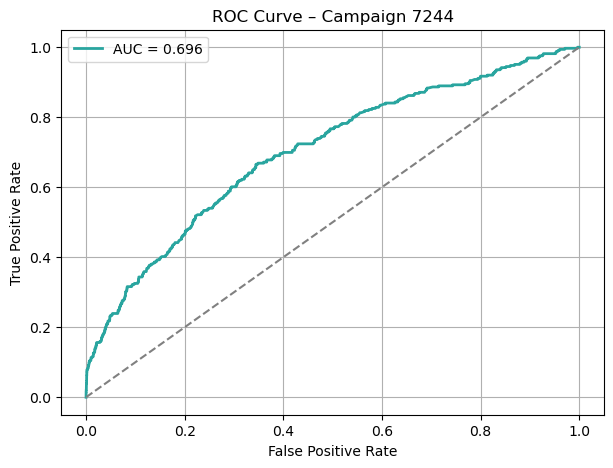

In [466]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba_7244)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", linewidth=2, color='#29a59f')
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Campaign 7244")
plt.legend()
plt.grid()
plt.show()

### 1. Feature Ranked by Importance in our model
Feature Ranked by Importance in our model

Loading model and feature names...


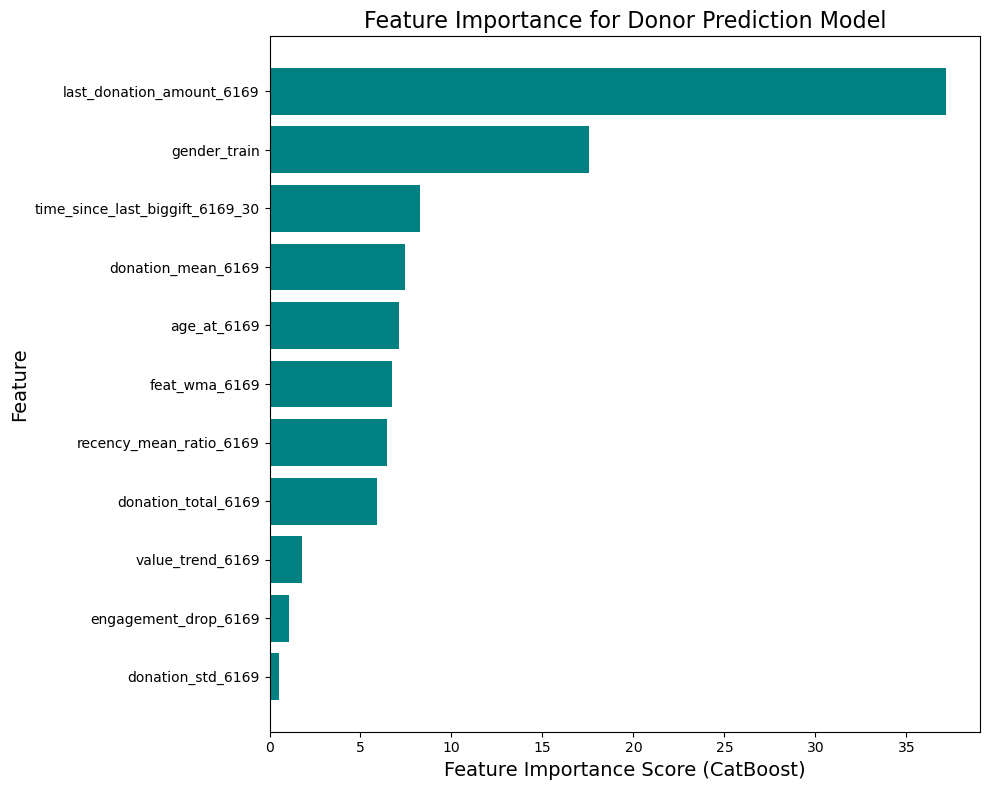


--- Plotting Complete ---
Saved Feature Importance Chart to 'feature_importance_bar_chart.png'


In [467]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# --- 1. FILE & COLUMN CONSTANTS ---
MODEL_FILE = 'catboost_best_model.joblib'
BASETABLE_FILE = 'basetable_7244_final_features.csv' 
TARGET_COLUMN = 'target_7244'
ID_COLUMN = 'donorID'

# ----------------------------------------------------------------------------------
# 2. Load Model and Features
# ----------------------------------------------------------------------------------
try:
    print("Loading model and feature names...")
    # Load the trained CatBoost model
    model = joblib.load(MODEL_FILE)
    
    # Load the base table just to extract the feature names in the correct order
    df_val = pd.read_csv(BASETABLE_FILE)
    
    # Define the list of feature columns
    FEATURE_COLUMNS = df_val.drop(columns=[TARGET_COLUMN, ID_COLUMN]).columns.tolist()

except FileNotFoundError as e:
    print(f"CRITICAL ERROR: Required file not found: {e.filename}")
    print("Please ensure your model and base table file are in the current directory.")
    raise

# ----------------------------------------------------------------------------------
# 3. Extract and Process Feature Importance
# ----------------------------------------------------------------------------------

# CatBoost method to get importance scores
importances = model.get_feature_importance()

# Create a DataFrame for easy handling
feature_importance_df = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'Importance': importances
}).sort_values(by='Importance', ascending=True) # Sort Ascending for Horizontal Bar Chart

# ----------------------------------------------------------------------------------
# 4. Generate and Save Plot
# ----------------------------------------------------------------------------------

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='teal')
plt.xlabel('Feature Importance Score (CatBoost)', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.title('Feature Importance for Donor Prediction Model', fontsize=16)
plt.tight_layout() # Ensures labels are not cut off

# Save the plot
plt.show()
plt.savefig('feature_importance_bar_chart.png')
plt.close()

print("\n--- Plotting Complete ---")
print("Saved Feature Importance Chart to 'feature_importance_bar_chart.png'")

### 2. Generate Lift and Cumulative Gain Curves
This requires a custom function or dedicated library (like scikitplot or yellowbrick) to generate the data for the curves requested by the CEO.


The principle is: Rank the test set data by probability, then calculate the cumulative positive responses.

Expected responders and cumulative metrics

In [468]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- INPUT: scored 7244 file ---
df = df_scored_output.copy()   # This must contain donorID + predicted probability

print("Total people scored (campaign 7244):", len(df))

# --- Sort donors by predicted probability (score) descending ---
df_sorted = df.sort_values("predicted", ascending=False).reset_index(drop=True)

N = len(df_sorted)

# Total expected responders = sum of probabilities
total_expected = df_sorted["predicted"].sum()

# Baseline (expected average response rate)
overall_rr = df_sorted["predicted"].mean()

print(f"Baseline expected response rate: {overall_rr*100:.2f}%")

# Cutoffs for analysis: 10%, 20%, 30%, 40%, 60%, 80%, 100%
cutoffs = [0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0]

rows = []
for p in cutoffs:
    n_mail = int(p * N)                       # number of donors mailed
    subset = df_sorted.iloc[:n_mail]          # top p% donors
    
    expected_cum = subset["predicted"].sum()  # cumulative expected responders
    
    cum_gain = expected_cum / total_expected  # % of all responders captured
    cum_rr = expected_cum / n_mail            # cumulative response rate

    rows.append({
        "cutoff": p,
        "cum_gain": cum_gain,
        "cum_response": cum_rr
    })

gains_df = pd.DataFrame(rows)
gains_df


Total people scored (campaign 7244): 26522
Baseline expected response rate: 29.05%


,cutoff,cum_gain,cum_response
0,0.1,0.293970,0.853923
1,0.2,0.521844,0.757926
2,0.3,0.690710,0.668791
3,0.4,0.803167,0.583260
4,0.6,0.917290,0.444063
5,0.8,0.980175,0.355885
6,1.0,1.000000,0.290458


Loading model and base table...
Generating predictions...


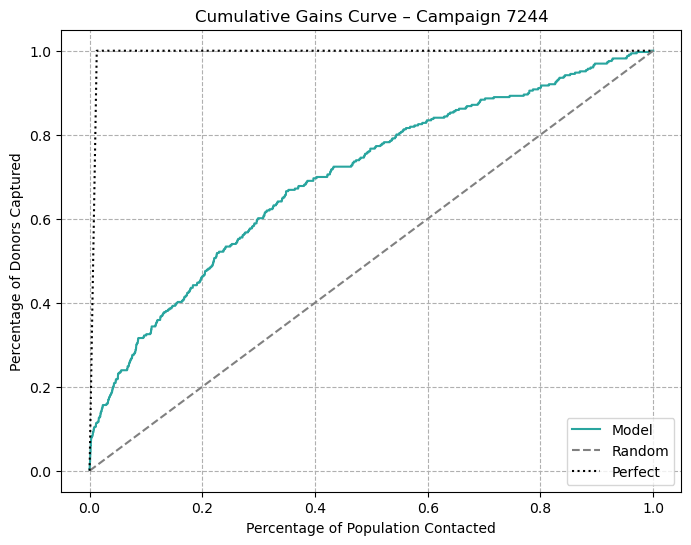

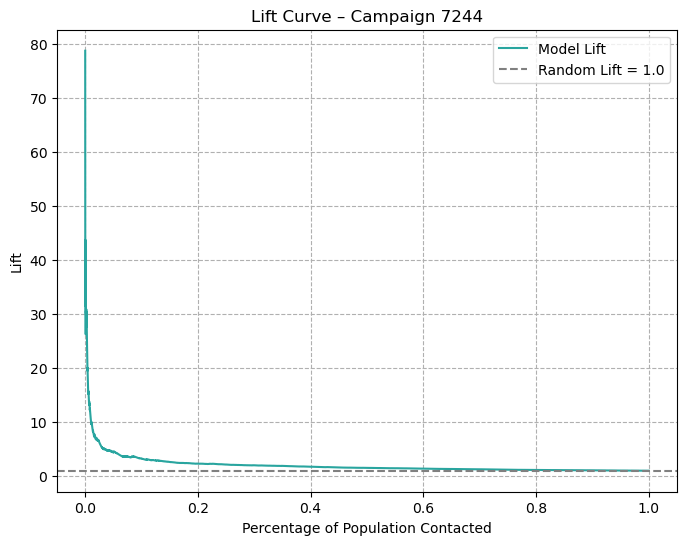


--- Plotting Complete ---
1. Saved Cumulative Gains Curve to 'cumulative_gains_curve.png'
2. Saved Lift Curve to 'lift_curve.png'


In [469]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# --- 1. FILE & COLUMN CONSTANTS ---
MODEL_FILE = 'catboost_best_model.joblib'
# The single file you have for Campaign 7244 evaluation:
BASETABLE_FILE = 'basetable_7244_final_features.csv' 
TARGET_COLUMN = 'target_7244'
ID_COLUMN = 'donorID'

# 2. Load Model and Test Data (Campaign 7244)
try:
    print("Loading model and base table...")
    model = joblib.load(MODEL_FILE)
    df_val = pd.read_csv(BASETABLE_FILE)
except FileNotFoundError as e:
    print(f"CRITICAL ERROR: Required file not found: {e.filename}")
    print("Please ensure your model and base table file are in the current directory.")
    raise

# 3. Define X_val and y_val from the Basetable

# Define the target variable (what actually happened)
y_val = df_val[TARGET_COLUMN]

# Define the feature matrix (what the model uses for prediction)
X_val = df_val.drop(columns=[TARGET_COLUMN, ID_COLUMN])

# 4. Predict Probabilities and Create Evaluation DataFrame

print("Generating predictions...")
y_pred_proba_7244 = model.predict_proba(X_val)[:, 1]

# Create evaluation DataFrame: Rank donors by model probability
df_eval = pd.DataFrame({
    'Target': y_val, 
    'Probability': y_pred_proba_7244
}).sort_values(by='Probability', ascending=False).reset_index(drop=True)

# 5. Calculate Cumulative Metrics for Plotting

# Sort donors by probability (already done earlier)
df_sorted = df_eval.copy()

N = len(df_sorted)
N_donors = df_sorted['Target'].sum()

# Cumulative donors caught
df_sorted['cum_donors'] = df_sorted['Target'].cumsum()

# Percentage of donors captured
df_sorted['cum_gain'] = df_sorted['cum_donors'] / N_donors

# Percentage of population contacted
df_sorted['cum_pct_population'] = (df_sorted.index + 1) / N

# Lift = cumulative gain / population %
df_sorted['lift'] = df_sorted['cum_gain'] / df_sorted['cum_pct_population']


# 6. Generate and Save Plots

# --- Plot 1: Cumulative Gains Curve ---
plt.figure(figsize=(8,6))
plt.plot(df_sorted['cum_pct_population'], df_sorted['cum_gain'], label="Model", color='#29a59f')
plt.plot([0,1],[0,1], linestyle='--', color='gray', label="Random")
plt.plot([0, N_donors/N, 1], [0,1,1], linestyle=':', color='black', label="Perfect")

plt.xlabel("Percentage of Population Contacted")
plt.ylabel("Percentage of Donors Captured")
plt.title("Cumulative Gains Curve – Campaign 7244")
plt.grid(True, linestyle='--')
plt.legend()
plt.savefig("cumulative_gains_curve.png")
plt.show()
plt.close()

# --- Plot 2: Lift Curve ---
plt.figure(figsize=(8,6))
plt.plot(df_sorted['cum_pct_population'], df_sorted['lift'], label="Model Lift", color='#29a59f')
plt.axhline(1, linestyle='--', color='gray', label="Random Lift = 1.0")

plt.xlabel("Percentage of Population Contacted")
plt.ylabel("Lift")
plt.title("Lift Curve – Campaign 7244")
plt.grid(True, linestyle='--')
plt.legend()
plt.savefig("lift_curve.png")
plt.show()
plt.savefig('lift_curve.png')
plt.close()


print("\n--- Plotting Complete ---")
print("1. Saved Cumulative Gains Curve to 'cumulative_gains_curve.png'")
print("2. Saved Lift Curve to 'lift_curve.png'")

### 3.Cumulative_response()
This requires a custom function or dedicated library (like scikitplot or yellowbrick) to generate the data for the curves requested by the CEO.


The principle is: Rank the test set data by probability, then calculate the cumulative positive responses.

In [470]:
def cumulative_response(y_true, y_prob, bins=5):
    """
    Compute cumulative response curve metrics.
    
    Parameters:
        y_true : array-like of real targets (0/1)
        y_prob : array-like of predicted probabilities
        bins   : number of buckets (default = 5, meaning 20%-20%-20%-20%-20%)

    Returns:
        metrics : DataFrame with cumulative response curve columns
    """

    df = pd.DataFrame({'y_true': y_true, 'y_prob': y_prob})
    df = df.sort_values('y_prob', ascending=False).reset_index(drop=True)

    # Assign bucket index by position
    df['bucket'] = pd.qcut(df.index, q=bins, labels=False, duplicates='drop')

    # Summaries per bucket
    metrics = df.groupby('bucket').agg(
        positives=('y_true', 'sum'),
        total=('y_true', 'count')
    ).reset_index()

    # Cumulative values
    metrics['cum_positives'] = metrics['positives'].cumsum()
    metrics['cum_total'] = metrics['total'].cumsum()

    # Percent of population contacted so far
    metrics['population_pct'] = metrics['cum_total'] / metrics['total'].sum()

    # Percent of all donors captured so far (gains)
    metrics['gain_pct'] = metrics['cum_positives'] / df['y_true'].sum()

    # TRUE cumulative response
    metrics['response_pct'] = metrics['cum_positives'] / metrics['cum_total']

    return metrics


In [471]:
def plot_cumulative_response(metrics, model_name="Model"):
    import matplotlib.ticker as mtick
    plt.figure(figsize=(8,5))

    # Plot cumulative response
    plt.plot(metrics['population_pct'], metrics['response_pct'], 
             marker='o', color="#29a59f", linewidth=3, label=model_name)

    # Baseline = total donors / total population
    baseline = metrics['cum_positives'].iloc[-1] / metrics['cum_total'].iloc[-1]
    plt.axhline(baseline, linestyle='--', color='gray', 
                label=f'Overall Rate = {baseline*100:.2f}%')

    plt.title("Cumulative Response Curve", fontsize=14)
    plt.xlabel("Population Contacted (%)")
    plt.ylabel("Response Rate (%)")

    # Format axes as %
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


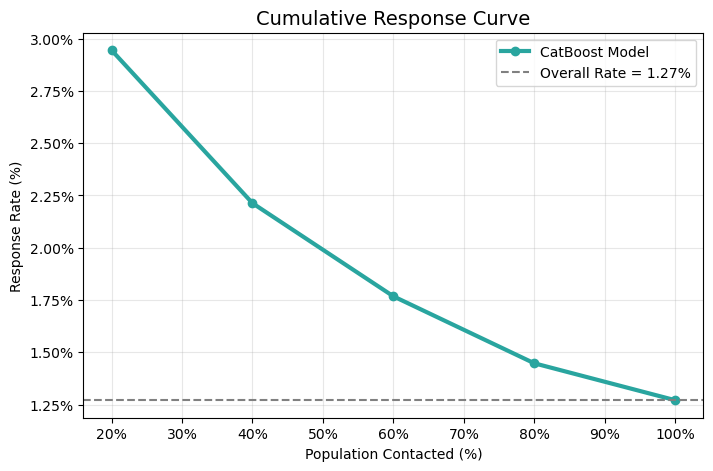

In [472]:
metrics7244 = cumulative_response(y_val, y_pred_proba_7244, bins=5)
plot_cumulative_response(metrics7244, model_name="CatBoost Model")


### 4. Profiling 

1. BASIC PROFILING: Donors vs. Non-donors

In [473]:
import pandas as pd

# Start from your existing df_val, which includes all features
df_profile = df_val.copy()  # includes pred_proba

# Define convenience variables
TARGET_COL = 'target_7244'
AGE_COL = 'age_at_6169'
GENDER_COL = 'gender_train'

# Split into donors and non-donors
donors = df_profile[df_profile[TARGET_COL] == 1]
non_donors = df_profile[df_profile[TARGET_COL] == 0]

print("=== BASIC COUNTS ===")
print("Donors:", len(donors))
print("Non-Donors:", len(non_donors))

print("\n=== AVERAGE AGE ===")
print("Donors mean age:", donors[AGE_COL].mean())
print("Non-Donors mean age:", non_donors[AGE_COL].mean())

print("\n=== GENDER DISTRIBUTION ===")
print("Donors:\n", donors[GENDER_COL].value_counts(normalize=True))
print("\nNon-Donors:\n", non_donors[GENDER_COL].value_counts(normalize=True))

print("\n=== DONATION HISTORY PROFILES ===")
cols_to_compare = [
    'donation_total_6169',
    'donation_mean_6169',
    'last_donation_amount_6169',
    'recency_mean_ratio_6169',
    'engagement_drop_6169',
    'value_trend_6169',
    'donation_std_6169',
    'time_since_last_biggift_6169_30'
]

donor_means = donors[cols_to_compare].mean().rename("Donors")
nondonor_means = non_donors[cols_to_compare].mean().rename("Non-Donors")

comparison_df = pd.concat([donor_means, nondonor_means], axis=1)
print(comparison_df)


=== BASIC COUNTS ===
Donors: 326
Non-Donors: 25319

=== AVERAGE AGE ===
Donors mean age: 51.745153374233126
Non-Donors mean age: 49.67248588016905

=== GENDER DISTRIBUTION ===
Donors:
 gender_train
0    0.564417
1    0.435583
Name: proportion, dtype: float64

Non-Donors:
 gender_train
1    0.603855
0    0.396145
Name: proportion, dtype: float64

=== DONATION HISTORY PROFILES ===
                                      Donors   Non-Donors
donation_total_6169                32.920153    12.838684
donation_mean_6169                 16.600306     9.128309
last_donation_amount_6169          17.033589     9.179666
recency_mean_ratio_6169            19.688481    34.444492
engagement_drop_6169                0.923313     0.992219
value_trend_6169                    0.490239     0.071832
donation_std_6169                   0.850738     0.395979
time_since_last_biggift_6169_30  1597.702454  1429.629290


2. PROFILE OF THE TOP 10% MOST LIKELY DONORS

This answers:
“Who does the model think is most likely to donate?

In [474]:
# Ensure prediction column exists
df_profile = df_val.copy()
df_profile['pred_proba'] = y_pred_proba_7244

# Top 10% cutoff
cutoff_10 = df_profile['pred_proba'].quantile(0.90)
top10 = df_profile[df_profile['pred_proba'] >= cutoff_10]
rest = df_profile[df_profile['pred_proba'] < cutoff_10]

print("=== TOP 10% PROFILE (Highest Predicted Donors) ===")
print("Count:", len(top10))

# Correct AGE column
print("\nAge (mean):", top10['age_at_6169'].mean())

# Correct GENDER column
print("\nGender Distribution:\n", top10['gender_train'].value_counts(normalize=True))

# You don't have a LANGUAGE column, so skip it


=== TOP 10% PROFILE (Highest Predicted Donors) ===
Count: 2572

Age (mean): 62.25024883359254

Gender Distribution:
 gender_train
0    0.984059
1    0.015941
Name: proportion, dtype: float64


3. COMPARE TOP 10% vs. Rest

This answers:
“How is our target audience different from the general population?

In [475]:
AGE_COL = 'age_at_6169'
GENDER_COL = 'gender_train'

# Make sure pred_proba exists
df_profile = df_val.copy()
df_profile['pred_proba'] = y_pred_proba_7244

# Top 10% cutoff
cutoff_10 = df_profile['pred_proba'].quantile(0.90)
top10 = df_profile[df_profile['pred_proba'] >= cutoff_10]
rest = df_profile[df_profile['pred_proba'] < cutoff_10]

print("=== TOP 10% PROFILE ===")
print("Count:", len(top10))

print("\nAverage age (Top 10%):", top10[AGE_COL].mean())
print("Average age (Rest):", rest[AGE_COL].mean())

print("\nGender distribution (Top 10%):\n", top10[GENDER_COL].value_counts(normalize=True))
print("\nGender distribution (Rest):\n", rest[GENDER_COL].value_counts(normalize=True))

# Donation history columns
cols_to_profile = [
    'donation_total_6169',
    'donation_mean_6169',
    'last_donation_amount_6169',
    'recency_mean_ratio_6169',
    'engagement_drop_6169',
    'value_trend_6169',
    'donation_std_6169',
    'time_since_last_biggift_6169_30'
]

top10_means = top10[cols_to_profile].mean().rename("Top 10%")
rest_means = rest[cols_to_profile].mean().rename("Rest")

profile_comparison = pd.concat([top10_means, rest_means], axis=1)
print("\n=== Donation Behavior Comparison (Top 10% vs Rest) ===")
print(profile_comparison)



=== TOP 10% PROFILE ===
Count: 2572

Average age (Top 10%): 62.25024883359254
Average age (Rest): 48.299698782126306

Gender distribution (Top 10%):
 gender_train
0    0.984059
1    0.015941
Name: proportion, dtype: float64

Gender distribution (Rest):
 gender_train
1    0.667013
0    0.332987
Name: proportion, dtype: float64

=== Donation Behavior Comparison (Top 10% vs Rest) ===
                                     Top 10%         Rest
donation_total_6169                13.683686    13.028222
donation_mean_6169                  8.153334     9.342564
last_donation_amount_6169           8.297135     9.389012
recency_mean_ratio_6169             8.150236    37.167084
engagement_drop_6169                0.984837     0.992069
value_trend_6169                    0.196554     0.063841
donation_std_6169                   0.370558     0.405238
time_since_last_biggift_6169_30  2188.380638  1347.424262


Visual Donor Profile Plots

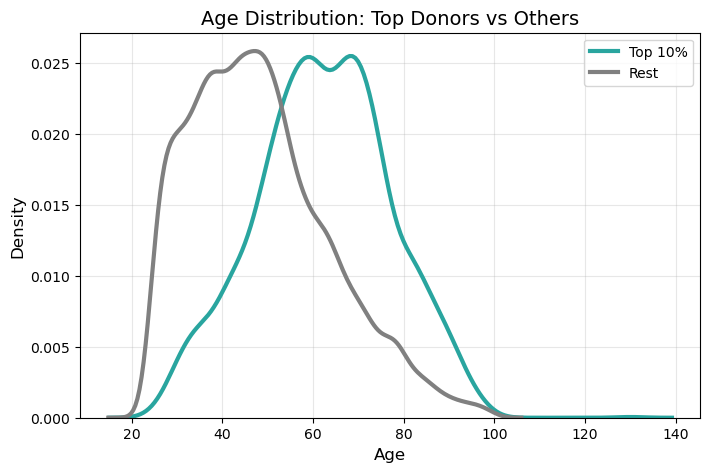

In [476]:
import seaborn as sns
plt.figure(figsize=(8,5))

sns.kdeplot(top10['age_at_6169'], label="Top 10%", linewidth=3, color="#29a59f")
sns.kdeplot(rest['age_at_6169'], label="Rest", linewidth=3, color="gray")

plt.title("Age Distribution: Top Donors vs Others", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.show()



<Figure size 600x400 with 0 Axes>

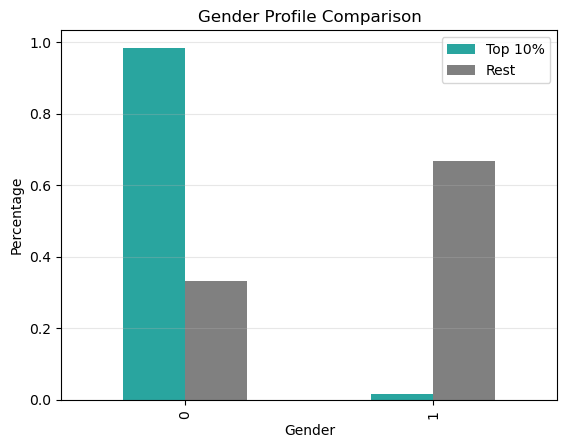

In [477]:
plt.figure(figsize=(6,4))

(pd.DataFrame({
    "Top 10%": top10['gender_train'].value_counts(normalize=True),
    "Rest": rest['gender_train'].value_counts(normalize=True)
})
.fillna(0)
.plot(kind='bar', color=["#29a59f", "gray"])
)

plt.title("Gender Profile Comparison")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.grid(axis='y', alpha=0.3)
plt.show()



In [ ]:
import pandas as pd

# Load data
df_7244 = pd.read_csv("../data/raw/selection_campaign_7244.csv", sep=",")
gifts = pd.read_csv("../data/raw/gifts.csv", sep=",")

gifts["amount"] = gifts["amount"].str.replace(",", ".", regex=False)
gifts["amount"] = pd.to_numeric(gifts["amount"], errors="coerce")
gifts["amount"].describe()
# Filter gifts belonging to campaign 7244 AND donors in the 7244 selection
gifts_7244 = gifts[
    (gifts["campaignID"] == 7244) &
    (gifts["donorID"].isin(df_7244["donorID"]))
]

# Compute the average donation
avg_donation_7244 = gifts_7244["amount"].mean()

print("Average donation for campaign 7244 (original donors): €", round(avg_donation_7244, 2))


Average donation for campaign 7244 (original donors): € 51.57


In [517]:
gifts.head()


,donorID,campaignID,amount,date
0,D100001,NaN,12.39,23/03/2004
1,D100001,1577.0,12.39,11/10/2007
2,D100001,1634.0,6.69,28/12/2007
3,D100001,1778.0,24.79,14/06/2008
4,D100001,1808.0,7.44,09/07/2008


In [518]:
basetable_7244_final_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25645 entries, 0 to 25644
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   donorID                          25645 non-null  object 
 1   target_7244                      25645 non-null  int64  
 2   last_donation_amount_6169        25645 non-null  float64
 3   donation_total_6169              25645 non-null  float64
 4   feat_wma_6169                    25645 non-null  float64
 5   donation_mean_6169               25645 non-null  float64
 6   gender_train                     25645 non-null  int32  
 7   recency_mean_ratio_6169          25645 non-null  float64
 8   engagement_drop_6169             25645 non-null  float64
 9   age_at_6169                      25645 non-null  float64
 10  value_trend_6169                 25645 non-null  float64
 11  donation_std_6169                25645 non-null  float64
 12  time_since_last_bi

In [539]:
import pandas as pd
import joblib
import numpy as np

# --- 1. LOAD MODEL ---
MODEL_FILE = 'catboost_best_model.joblib' 
model = joblib.load(MODEL_FILE)

# --- 2. LOAD FEATURE BASE TABLE FOR 7244 ---
df_7244 = basetable_7244_final_features.copy()

# ==============================================================
# === 3. ADD TARGET + AMOUNT TO FEATURE TABLE (≥ €30 RULE) ====
# ==============================================================

# Ensure gifts has date in datetime format
gifts["date"] = pd.to_datetime(gifts["date"])

# Target window
test_target_start = pd.Timestamp("2019-06-18")
test_target_end   = pd.Timestamp("2019-12-18")

# Extract gifts in target window
gifts_7244 = gifts[
    (gifts["campaignID"] == 7244) &
    (gifts["donorID"].isin(df_7244["donorID"]))
]

donation_sum = gifts_7244.groupby("donorID")["amount"].sum()

# Add amount
df_7244["amount"] = df_7244["donorID"].map(donation_sum).fillna(0)

# Add target (≥ €30)
df_7244["target"] = (df_7244["amount"] >= 30).astype(int)

print("Target distribution:")
print(df_7244["target"].value_counts())

# ==============================================================
# === 4. PREPARE FEATURE MATRIX FOR PREDICTION ================
# ==============================================================

FEATURE_COLUMNS = [
    col for col in df_7244.columns 
    if col not in ["donorID", "amount", "target"]
]

X_7244 = df_7244[FEATURE_COLUMNS]
print(f"Using {len(FEATURE_COLUMNS)} features for prediction.")

# ==============================================================
# === 5. PREDICT PROBABILITIES ================================
# ==============================================================

df_7244["proba"] = model.predict_proba(X_7244)[:, 1]

# ==============================================================
# === 6. SAVE SCORED OUTPUT ===================================
# ==============================================================

df_7244[["donorID", "proba"]].to_csv("scored_campaign_7244.csv", index=False)

print("Predictions saved for campaign 7244.")


Target distribution:
target
0    25308
1      337
Name: count, dtype: int64
Using 13 features for prediction.
Predictions saved for campaign 7244.


In [540]:
print(len(df_7244))
print(len(FEATURE_COLUMNS))
print(df_7244.head())



25645
13
   donorID  target_7244  last_donation_amount_6169  donation_total_6169  \
0  D100001            0                        0.0                  0.0   
1  D100002            0                       20.0                 20.0   
2  D100008            0                        0.0                  0.0   
3  D100009            0                        0.0                  0.0   
4  D100010            0                       40.0                 40.0   

   feat_wma_6169  donation_mean_6169  gender_train  recency_mean_ratio_6169  \
0            0.0                 0.0             0                    0.000   
1           20.0                20.0             1                   80.600   
2            0.0                 0.0             1                    0.000   
3            0.0                 0.0             1                    0.000   
4           40.0                40.0             1                   40.225   

   engagement_drop_6169  age_at_6169  value_trend_6169  donation_

In [541]:
# ==============================================================
# === BUSINESS CASE: MODEL VS RANDOM FOR CAMPAIGN 7244 =========
# ==============================================================

cost_per_letter = 0.80
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

df_sorted = df_7244.sort_values(by="proba", ascending=False).reset_index(drop=True)
N = len(df_sorted)

# --------------------------------------------------------------
# 1. CAMPAIGN 7244 RESPONSE STATISTICS (GROUND TRUTH)
# --------------------------------------------------------------

# responders to campaign 7244
responders_7244 = gifts_7244["donorID"].nunique()

# average donation in campaign 7244
avg_donation = gifts_7244["amount"].mean()

# base random response rate for THIS campaign
random_response_rate = responders_7244 / N

print("Average campaign donation:", avg_donation)
print("Responders:", responders_7244)
print("Base response rate:", random_response_rate)

# --------------------------------------------------------------
# 2. BUSINESS CASE CALCULATION
# --------------------------------------------------------------

model_rows = []
random_rows = []

for frac in fractions:
    k = int(frac * N)
    contacted = df_sorted.iloc[:k]

    # =============================
    # MODEL: predicted responders
    # =============================
    # count of donors in contacted pool who actually donated to campaign 7244
    contacted_donors = contacted["donorID"]

    model_resp = gifts_7244[gifts_7244["donorID"].isin(contacted_donors)]["donorID"].nunique()

    revenue_model = model_resp * avg_donation
    cost_model = k * cost_per_letter
    profit_model = revenue_model - cost_model

    model_rows.append([
        frac, k,
        model_resp / k,
        model_resp,
        cost_model,
        revenue_model,
        profit_model
    ])

    # =============================
    # RANDOM: expected responders
    # =============================
    expected_resp_random = random_response_rate * k
    revenue_random = expected_resp_random * avg_donation
    cost_random = k * cost_per_letter
    profit_random = revenue_random - cost_random

    random_rows.append([
        frac, k,
        random_response_rate,
        expected_resp_random,
        cost_random,
        revenue_random,
        profit_random
    ])

model_df = pd.DataFrame(model_rows, columns=[
    "Fraction","Num_Contacted","Cum_Response_Model",
    "Num_Customers_Model","Cost_Model","Revenue_Model","Profit_Model"
])

random_df = pd.DataFrame(random_rows, columns=[
    "Fraction","Num_Contacted","Cum_Response_Random",
    "Num_Customers_Random","Cost_Random",
    "Revenue_Random","Profit_Random"
])

print("\n=== MODEL RESULTS ===")
print(model_df)

print("\n=== RANDOM BASELINE RESULTS ===")
print(random_df)


Average campaign donation: 51.56786703601108
Responders: 361
Base response rate: 0.014076818093195555

=== MODEL RESULTS ===
   Fraction  Num_Contacted  Cum_Response_Model  Num_Customers_Model  \
0       0.2           5129            0.028661                  147   
1       0.4          10258            0.022324                  229   
2       0.6          15387            0.017612                  271   
3       0.8          20516            0.015646                  321   
4       1.0          25645            0.014077                  361   

   Cost_Model  Revenue_Model  Profit_Model  
0      4103.2    7580.476454   3477.276454  
1      8206.4   11809.041551   3602.641551  
2     12309.6   13974.891967   1665.291967  
3     16412.8   16553.285319    140.485319  
4     20516.0   18616.000000  -1900.000000  

=== RANDOM BASELINE RESULTS ===
   Fraction  Num_Contacted  Cum_Response_Random  Num_Customers_Random  \
0       0.2           5129             0.014077                  72.2   

In [542]:
print("len(df_7244):", len(df_7244))
print("len(probabilities):", len(probabilities))


len(df_7244): 25645
len(probabilities): 26522


1. Lift Curve

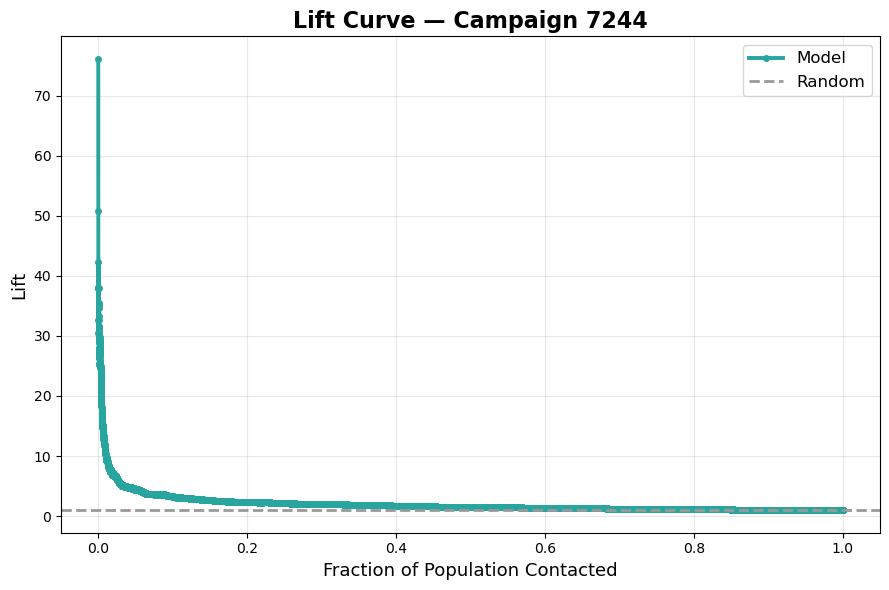

In [546]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare sorted dataframe
df_sorted = df_7244.sort_values("proba", ascending=False).reset_index(drop=True)
df_sorted["cum_responders"] = df_sorted["target"].cumsum()

total_responders = df_sorted["target"].sum()
df_sorted["cum_pct"] = (np.arange(len(df_sorted)) + 1) / len(df_sorted)
df_sorted["cum_resp_pct"] = df_sorted["cum_responders"] / total_responders
df_sorted["lift"] = df_sorted["cum_resp_pct"] / df_sorted["cum_pct"]

plt.figure(figsize=(9,6))
plt.plot(df_sorted["cum_pct"], df_sorted["lift"],
         color="#29a59f", linewidth=2.8, marker="o", markersize=4,
         label="Model")
plt.axhline(1, linestyle="--", color="#999999", linewidth=2,
            label="Random")

plt.title("Lift Curve — Campaign 7244", fontsize=16, weight="bold")
plt.xlabel("Fraction of Population Contacted", fontsize=13)
plt.ylabel("Lift", fontsize=13)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()




gains chart

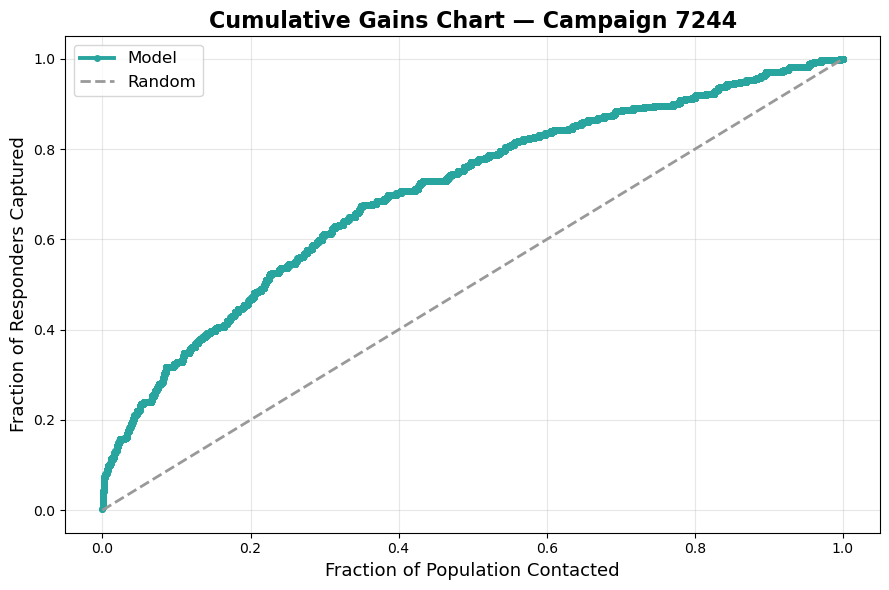

In [547]:
plt.figure(figsize=(9,6))
plt.plot(df_sorted["cum_pct"], df_sorted["cum_resp_pct"],
         color="#29a59f", linewidth=2.8, marker="o", markersize=4,
         label="Model")

plt.plot([0,1], [0,1],
         linestyle="--", color="#999999", linewidth=2,
         label="Random")

plt.title("Cumulative Gains Chart — Campaign 7244", fontsize=16, weight='bold')
plt.xlabel("Fraction of Population Contacted", fontsize=13)
plt.ylabel("Fraction of Responders Captured", fontsize=13)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()



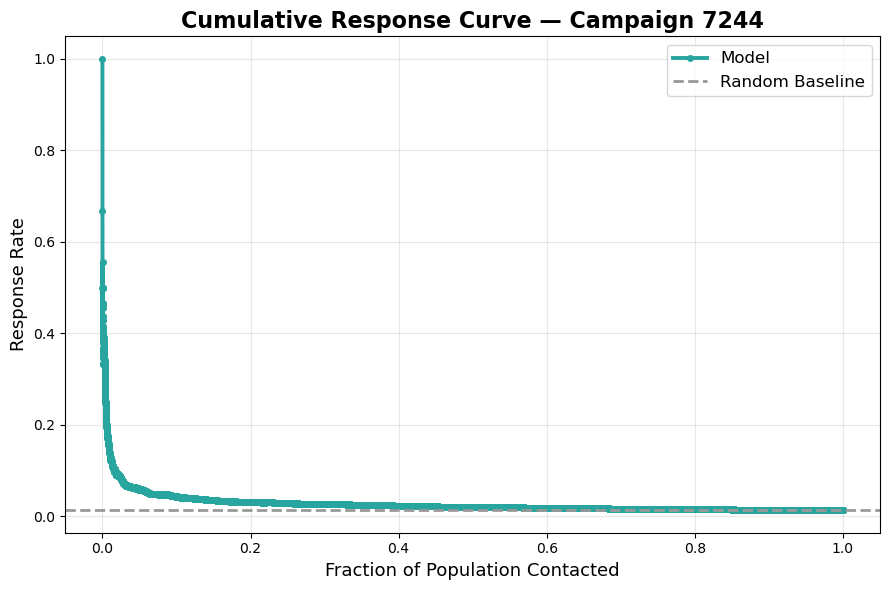

In [548]:
df_sorted["rolling_response"] = df_sorted["target"].expanding().mean()

plt.figure(figsize=(9,6))
plt.plot(df_sorted["cum_pct"], df_sorted["rolling_response"],
         color="#29a59f", linewidth=2.8, marker="o", markersize=4,
         label="Model")

plt.axhline(df_sorted["target"].mean(),
            linestyle="--", color="#999999", linewidth=2,
            label="Random Baseline")

plt.title("Cumulative Response Curve — Campaign 7244", fontsize=16, weight="bold")
plt.xlabel("Fraction of Population Contacted", fontsize=13)
plt.ylabel("Response Rate", fontsize=13)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [549]:
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
cost_per_letter = 0.80

df_sorted = df_7244.sort_values("proba", ascending=False).reset_index(drop=True)
N = len(df_sorted)

# Correct baseline stats
total_responders = df_7244["target"].sum()
random_response_rate = total_responders / N
avg_donation = df_7244.loc[df_7244["target"] == 1, "amount"].mean()

model_rows = []
random_rows = []

for frac in fractions:
    k = int(frac * N)
    contacted = df_sorted.iloc[:k]

    # ===== MODEL =====
    model_resp = contacted["target"].sum()
    model_revenue = contacted.loc[contacted["target"] == 1, "amount"].sum()
    model_cost = k * cost_per_letter
    model_profit = model_revenue - model_cost

    model_rows.append([
        frac, k, model_resp/k, model_resp, model_cost, model_revenue, model_profit
    ])

    # ===== RANDOM BASELINE (corrected) =====
    random_resp = random_response_rate * k
    random_revenue = random_resp * avg_donation
    random_cost = k * cost_per_letter
    random_profit = random_revenue - random_cost   # THIS WILL BE NEGATIVE

    random_rows.append([
        frac, k, random_response_rate, random_resp,
        random_cost, random_revenue, random_profit
    ])

model_df = pd.DataFrame(model_rows, columns=[
    "Fraction","Num_Contacted","Cum_Response_Model","Num_Customers_Model",
    "Cost_Model","Revenue_Model","Profit_Model"
])

random_df = pd.DataFrame(random_rows, columns=[
    "Fraction","Num_Contacted","Cum_Response_Random",
    "Num_Customers_Random","Cost_Random",
    "Revenue_Random","Profit_Random"
])


In [538]:
print("Average donation amount (responders only):",
      df_7244.loc[df_7244["target"] == 1, "amount"].mean())

print("Total responders:", df_7244["target"].sum())
print("Total donors:", len(df_7244))
print("Base response rate:", df_7244["target"].sum() / len(df_7244))


Average donation amount (responders only): 74.80712166172107
Total responders: 337
Total donors: 25645
Base response rate: 0.01314096315071164


In [553]:
model_df
random_df


,Fraction,Num_Contacted,Cum_Response_Random,Num_Customers_Random,Cost_Random,Revenue_Random,Profit_Random
0,0.2,5129,0.013141,67.4,4103.2,5042.0,938.8
1,0.4,10258,0.013141,134.8,8206.4,10084.0,1877.6
2,0.6,15387,0.013141,202.2,12309.6,15126.0,2816.4
3,0.8,20516,0.013141,269.6,16412.8,20168.0,3755.2
4,1.0,25645,0.013141,337.0,20516.0,25210.0,4694.0


True optimal contact rate


In [551]:
import numpy as np
import pandas as pd

cost_per_letter = 0.80

# 1. Sort donors by probability
df_sorted = df_7244.sort_values("proba", ascending=False).reset_index(drop=True)
N = len(df_sorted)

# 2. Create a vector showing WHO actually responded to campaign 7244
responders_7244_set = set(gifts_7244["donorID"])
df_sorted["is_campaign_responder"] = df_sorted["donorID"].isin(responders_7244_set).astype(int)

# 3. Compute cumulative responders if we contact the top k donors
df_sorted["cum_campaign_responders"] = df_sorted["is_campaign_responder"].cumsum()

# 4. Compute profit for every k = 1 to N
profits = []
for k in range(1, N+1):
    num_resp = df_sorted.loc[:k-1, "is_campaign_responder"].sum()
    revenue = num_resp * avg_donation_7244      # ~€51.56
    cost = k * cost_per_letter
    profit = revenue - cost
    profits.append(profit)

# 5. Find the best contact point
profits = np.array(profits)
best_k = profits.argmax() + 1
best_fraction = best_k / N
best_profit = profits.max()

best_k, best_fraction, best_profit


(8344, 0.3253655683369078, 4566.595013850414)

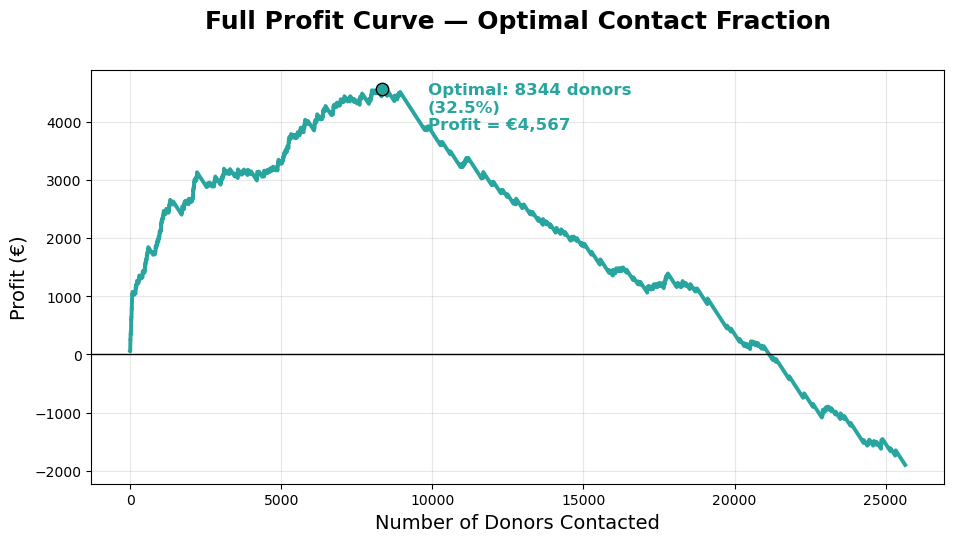

In [573]:
import matplotlib.pyplot as plt
import numpy as np

# Compute full profit curve
cost_per_letter = 0.80

df_sorted = df_7244.sort_values("proba", ascending=False).reset_index(drop=True)
N = len(df_sorted)

responders_7244_set = set(gifts_7244["donorID"])
df_sorted["is_campaign_responder"] = df_sorted["donorID"].isin(responders_7244_set).astype(int)
df_sorted["cum_campaign_responders"] = df_sorted["is_campaign_responder"].cumsum()

profits = []
for k in range(1, N+1):
    num_resp = df_sorted.loc[:k-1, "is_campaign_responder"].sum()
    revenue = num_resp * avg_donation_7244
    cost = k * cost_per_letter
    profits.append(revenue - cost)

profits = np.array(profits)

best_k = profits.argmax() + 1
best_fraction = best_k / N
best_profit = profits.max()

plt.figure(figsize=(11,6))

plt.plot(np.arange(1, N+1), profits,
         color="#29a59f", linewidth=2.8)

plt.scatter(best_k, best_profit, color="#29a59f", s=80, edgecolor="black", zorder=5)

# --- FIX HERE: move annotation DOWN and RIGHT ---
plt.text(best_k + 1500, best_profit - 700,       # moving down by 700 instead of 350
         f"Optimal: {best_k} donors\n({best_fraction:.1%})\nProfit = €{best_profit:,.0f}",
         fontsize=12, weight="bold", color="#29a59f")

# Zero line
plt.axhline(0, color="black", linewidth=1)

# --- FIX HERE: give title more space ---
plt.title("Full Profit Curve — Optimal Contact Fraction",
          fontsize=18, weight="bold", pad=30)

plt.xlabel("Number of Donors Contacted", fontsize=14)
plt.ylabel("Profit (€)", fontsize=14)
plt.grid(alpha=0.3)

# --- FIX HERE: increase top margin ---
plt.subplots_adjust(top=0.80)

plt.show()


In [554]:
# -------------------------
# USE CAMPAIGN 7244 DATA
# -------------------------

# responders to campaign 7244
responders_7244 = gifts_7244["donorID"].nunique()

# average donation for campaign 7244
avg_donation = gifts_7244["amount"].mean()

# true random response rate
random_response_rate = responders_7244 / len(df_7244)

print("Campaign responders:", responders_7244)
print("Avg campaign donation:", avg_donation)
print("Random response rate:", random_response_rate)

# -------------------------
# REBUILD BUSINESS CASE
# -------------------------

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
model_rows = []
random_rows = []

for frac in fractions:
    k = int(frac * len(df_sorted))
    contacted = df_sorted.iloc[:k]

    # MODEL: count


Campaign responders: 361
Avg campaign donation: 51.56786703601108
Random response rate: 0.014076818093195555


In [556]:
# ===============================================================
# BUSINESS CASE FOR CAMPAIGN 7244 USING CORRECT CAMPAIGN DATA
# ===============================================================

cost_per_letter = 0.80
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

df_sorted = df_7244.sort_values("proba", ascending=False).reset_index(drop=True)
N = len(df_sorted)

# ------------------------------------
# 1. True campaign responders
# ------------------------------------
responders_7244 = gifts_7244["donorID"].nunique()
avg_donation = gifts_7244["amount"].mean()
random_response_rate = responders_7244 / N   # ~1.4077%

print("Responders 7244:", responders_7244)
print("Avg donation 7244:", avg_donation)
print("Random response rate:", random_response_rate)

model_rows = []
random_rows = []

for frac in fractions:
    k = int(frac * N)
    contacted = df_sorted.iloc[:k]["donorID"]

    # -------------------------
    # MODEL revenue: 
    # how many of these donors actually responded to CAMPAIGN 7244?
    # -------------------------
    model_resp = gifts_7244[gifts_7244["donorID"].isin(contacted)]["donorID"].nunique()
    revenue_model = model_resp * avg_donation
    cost_model = k * cost_per_letter
    profit_model = revenue_model - cost_model

    model_rows.append([frac, k, model_resp/k, model_resp, cost_model, revenue_model, profit_model])

    # -------------------------
    # RANDOM revenue: expected values
    # -------------------------
    expected_resp_random = random_response_rate * k
    revenue_random = expected_resp_random * avg_donation
    cost_random = k * cost_per_letter
    profit_random = revenue_random - cost_random

    random_rows.append([frac, k, random_response_rate, expected_resp_random, cost_random, revenue_random, profit_random])

model_df = pd.DataFrame(model_rows, columns=[
    "Fraction","Num_Contacted","Cum_Response_Model",
    "Num_Customers_Model","Cost_Model","Revenue_Model","Profit_Model"
])

random_df = pd.DataFrame(random_rows, columns=[
    "Fraction","Num_Contacted","Cum_Response_Random",
    "Num_Customers_Random","Cost_Random","Revenue_Random","Profit_Random"
])

model_df, random_df


Responders 7244: 361
Avg donation 7244: 51.56786703601108
Random response rate: 0.014076818093195555


(   Fraction  Num_Contacted  Cum_Response_Model  Num_Customers_Model  \
 0       0.2           5129            0.028661                  147   
 1       0.4          10258            0.022324                  229   
 2       0.6          15387            0.017612                  271   
 3       0.8          20516            0.015646                  321   
 4       1.0          25645            0.014077                  361   
 
    Cost_Model  Revenue_Model  Profit_Model  
 0      4103.2    7580.476454   3477.276454  
 1      8206.4   11809.041551   3602.641551  
 2     12309.6   13974.891967   1665.291967  
 3     16412.8   16553.285319    140.485319  
 4     20516.0   18616.000000  -1900.000000  ,
    Fraction  Num_Contacted  Cum_Response_Random  Num_Customers_Random  \
 0       0.2           5129             0.014077                  72.2   
 1       0.4          10258             0.014077                 144.4   
 2       0.6          15387             0.014077                 21

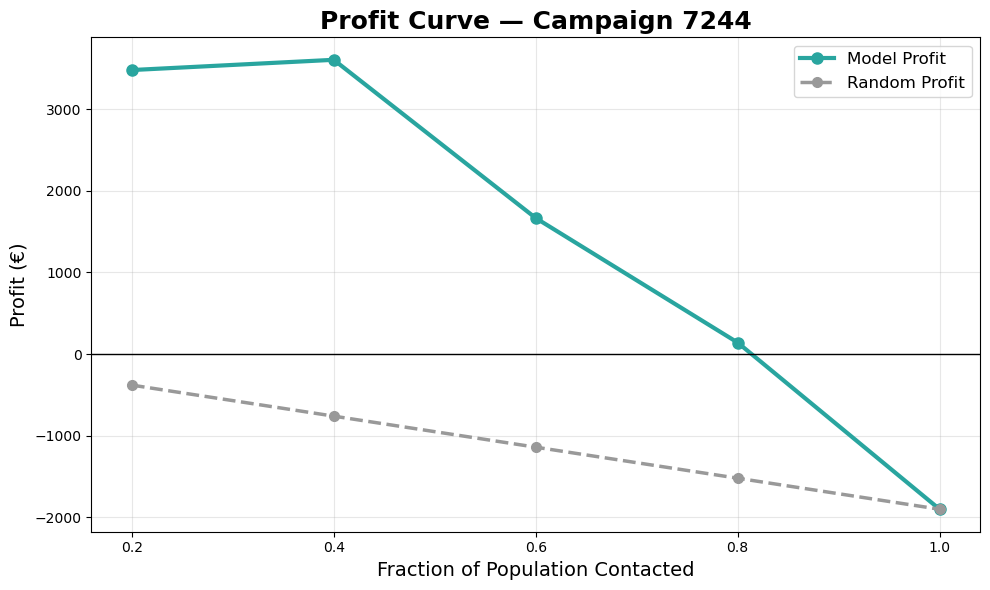

In [557]:
plt.figure(figsize=(10,6))

# Model Profit (correct)
plt.plot(model_df["Fraction"], model_df["Profit_Model"],
         color="#29a59f", linewidth=3, marker="o", markersize=8,
         label="Model Profit")

# Random Profit (correct)
plt.plot(random_df["Fraction"], random_df["Profit_Random"],
         color="#999999", linestyle="--", linewidth=2.5,
         marker="o", markersize=7,
         label="Random Profit")

plt.axhline(0, color="black", linewidth=1)

plt.title("Profit Curve — Campaign 7244", fontsize=18, weight="bold")
plt.xlabel("Fraction of Population Contacted", fontsize=14)
plt.ylabel("Profit (€)", fontsize=14)
plt.grid(alpha=0.3)
plt.xticks(model_df["Fraction"])
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [558]:
# ===============================================================
# REVENUE & PROFIT TABLE FOR CAMPAIGN 7244 (CORRECTED)
# ===============================================================

revprofit_rows = []

for i in range(len(model_df)):
    frac = model_df.loc[i, "Fraction"]
    contacted = model_df.loc[i, "Num_Contacted"]

    # MODEL
    rev_model = model_df.loc[i, "Revenue_Model"]
    prof_model = model_df.loc[i, "Profit_Model"]

    # RANDOM
    rev_random = random_df.loc[i, "Revenue_Random"]
    prof_random = random_df.loc[i, "Profit_Random"]

    revprofit_rows.append([
        frac,
        contacted,
        round(rev_model, 2),
        round(prof_model, 2),
        round(rev_random, 2),
        round(prof_random, 2)
    ])

revprofit_df = pd.DataFrame(
    revprofit_rows,
    columns=[
        "Fraction Contacted",
        "Num Contacted",
        "Revenue (Model)",
        "Profit (Model)",
        "Revenue (Random)",
        "Profit (Random)"
    ]
)

revprofit_df


,Fraction Contacted,Num Contacted,Revenue (Model),Profit (Model),Revenue (Random),Profit (Random)
0,0.2,5129,7580.48,3477.28,3723.2,-380.0
1,0.4,10258,11809.04,3602.64,7446.4,-760.0
2,0.6,15387,13974.89,1665.29,11169.6,-1140.0
3,0.8,20516,16553.29,140.49,14892.8,-1520.0
4,1.0,25645,18616.00,-1900.00,18616.0,-1900.0


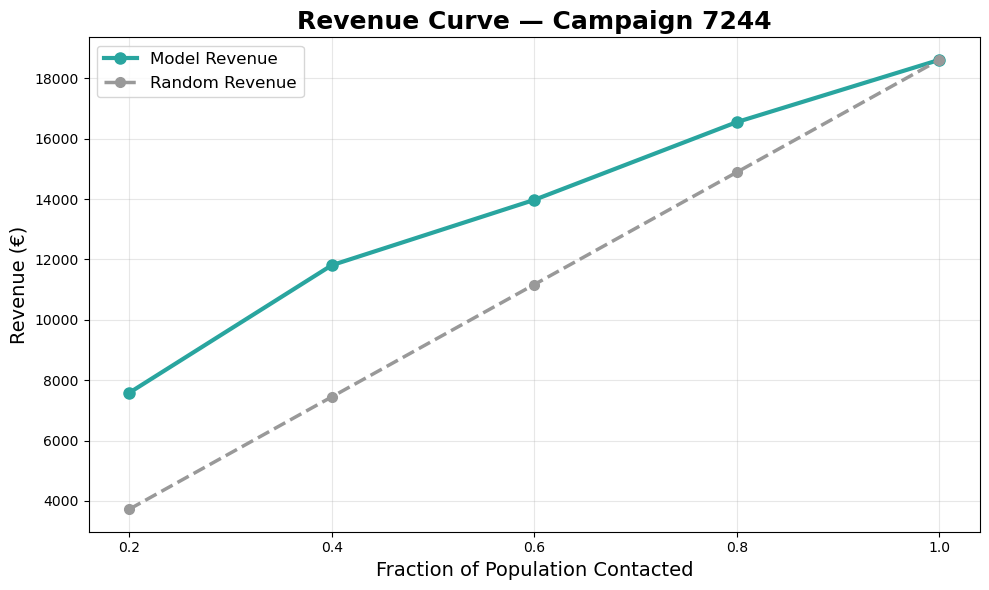

In [559]:
import matplotlib.pyplot as plt

fractions = model_df["Fraction"]

plt.figure(figsize=(10,6))

# Model Revenue
plt.plot(fractions, model_df["Revenue_Model"],
         color="#29a59f", linewidth=3, marker="o", markersize=8,
         label="Model Revenue")

# Random Revenue
plt.plot(fractions, random_df["Revenue_Random"],
         color="#999999", linestyle="--", linewidth=2.5,
         marker="o", markersize=7,
         label="Random Revenue")

plt.title("Revenue Curve — Campaign 7244", fontsize=18, weight="bold")
plt.xlabel("Fraction of Population Contacted", fontsize=14)
plt.ylabel("Revenue (€)", fontsize=14)
plt.grid(alpha=0.3)
plt.xticks(fractions)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


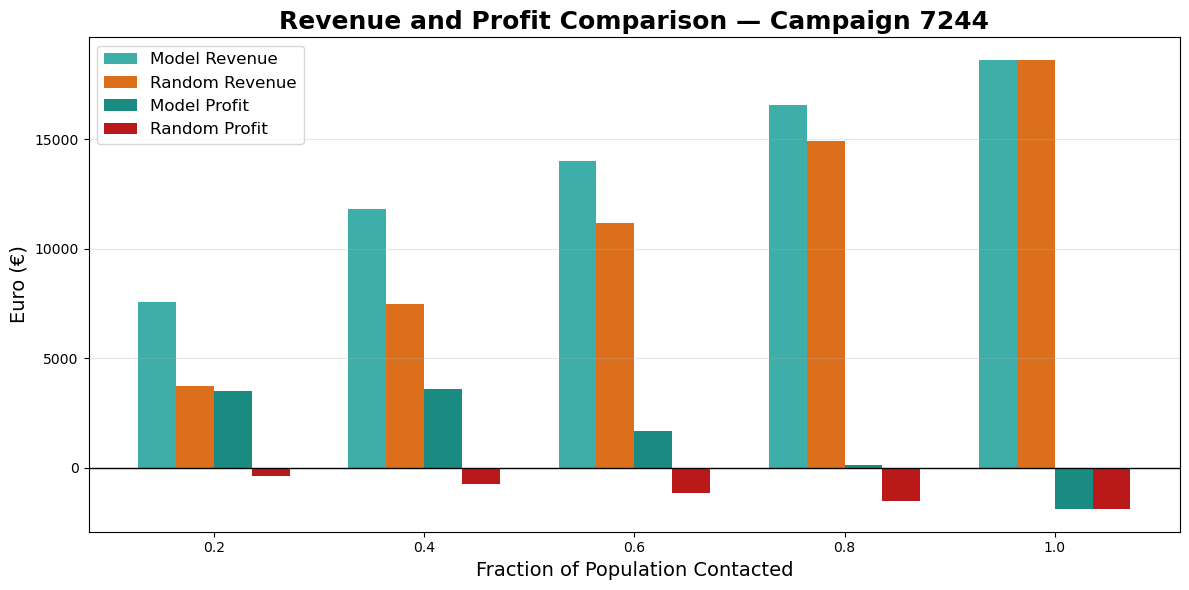

In [561]:
import numpy as np
import matplotlib.pyplot as plt

fractions = model_df["Fraction"]
x = np.arange(len(fractions))
width = 0.18

plt.figure(figsize=(12,6))

# -----------------------
# Revenue Bars
# -----------------------

# Model revenue (teal)
plt.bar(x - width*1.5, model_df["Revenue_Model"], width, 
        label='Model Revenue', color="#29a59f", alpha=0.9)

# Random revenue (strong orange)
plt.bar(x - width*0.5, random_df["Revenue_Random"], width,
        label='Random Revenue', color="#d95f02", alpha=0.9)

# -----------------------
# Profit Bars
# -----------------------

# Model profit (darker teal)
plt.bar(x + width*0.5, model_df["Profit_Model"], width,
        label='Model Profit', color="#007f73", alpha=0.9)

# Random profit (deep red)
plt.bar(x + width*1.5, random_df["Profit_Random"], width,
        label='Random Profit', color="#b30000", alpha=0.9)

# -----------------------
# Styling
# -----------------------

plt.xticks(x, fractions)
plt.xlabel("Fraction of Population Contacted", fontsize=14)
plt.ylabel("Euro (€)", fontsize=14)
plt.title("Revenue and Profit Comparison — Campaign 7244",
          fontsize=18, weight="bold")

plt.axhline(0, color="black", linewidth=1)
plt.legend(fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


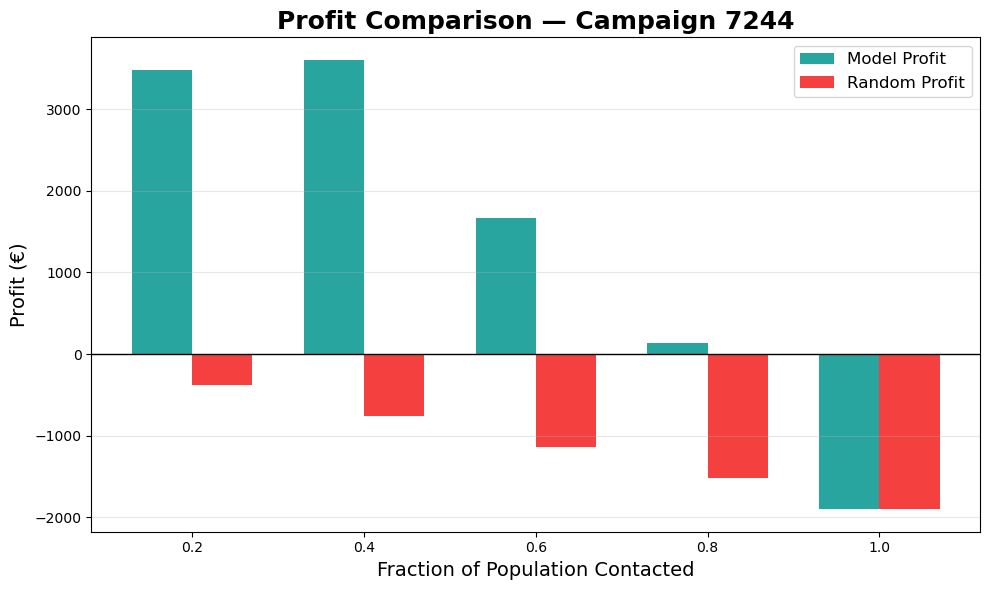

In [569]:
import numpy as np
import matplotlib.pyplot as plt

fractions = model_df["Fraction"]
x = np.arange(len(fractions))
width = 0.35

plt.figure(figsize=(10,6))

# Model profit bars (teal)
plt.bar(x - width/2, model_df["Profit_Model"], width,
        label='Model Profit', color="#29a59f")

# Random profit bars (red)
plt.bar(x + width/2, random_df["Profit_Random"], width,
        label='Random Profit', color="#f54040")

plt.axhline(0, color="black", linewidth=1)

plt.xticks(x, fractions)
plt.xlabel("Fraction of Population Contacted", fontsize=14)
plt.ylabel("Profit (€)", fontsize=14)
plt.title("Profit Comparison — Campaign 7244", fontsize=18, weight="bold")

plt.legend(fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


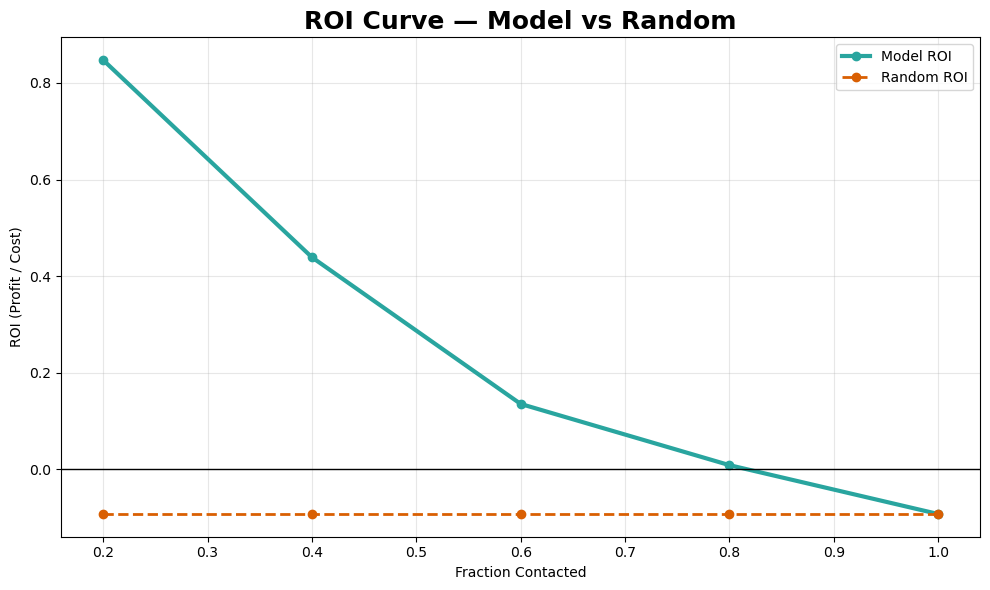

In [574]:
import matplotlib.pyplot as plt

# ROI = Profit / Cost
roi_model = model_df["Profit_Model"] / model_df["Cost_Model"]
roi_random = random_df["Profit_Random"] / random_df["Cost_Random"]

plt.figure(figsize=(10,6))

plt.plot(model_df["Fraction"], roi_model,
         color="#29a59f", marker="o", linewidth=3, label="Model ROI")

plt.plot(random_df["Fraction"], roi_random,
         color="#d95f02", marker="o", linestyle="--", linewidth=2, label="Random ROI")

plt.axhline(0, color="black", linewidth=1)
plt.title("ROI Curve — Model vs Random", fontsize=18, weight="bold")
plt.xlabel("Fraction Contacted")
plt.ylabel("ROI (Profit / Cost)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


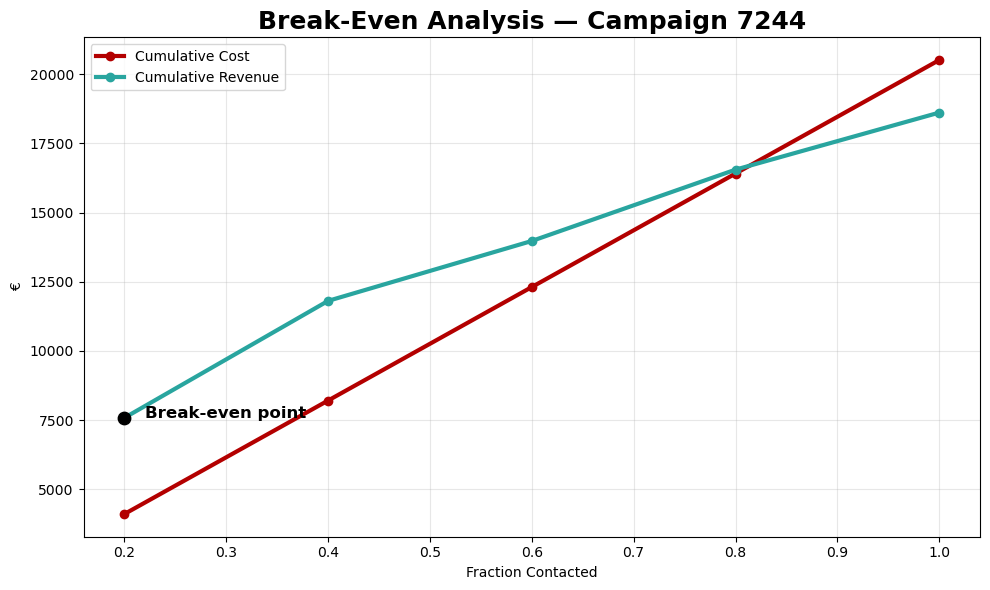

In [575]:
import numpy as np
import matplotlib.pyplot as plt

fractions = model_df["Fraction"]
cumulative_cost = model_df["Cost_Model"]
cumulative_revenue = model_df["Revenue_Model"]

plt.figure(figsize=(10,6))

plt.plot(fractions, cumulative_cost, 
         color="#b30000", linewidth=3, marker="o", label="Cumulative Cost")

plt.plot(fractions, cumulative_revenue, 
         color="#29a59f", linewidth=3, marker="o", label="Cumulative Revenue")

# Break-even point
idx = np.where(cumulative_revenue >= cumulative_cost)[0][0]
plt.scatter(fractions[idx], cumulative_revenue[idx], 
            color="black", s=80, zorder=5)

plt.text(fractions[idx] + 0.02, cumulative_revenue[idx],
         "Break-even point", fontsize=12, weight="bold")

plt.title("Break-Even Analysis — Campaign 7244", fontsize=18, weight="bold")
plt.xlabel("Fraction Contacted")
plt.ylabel("€")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


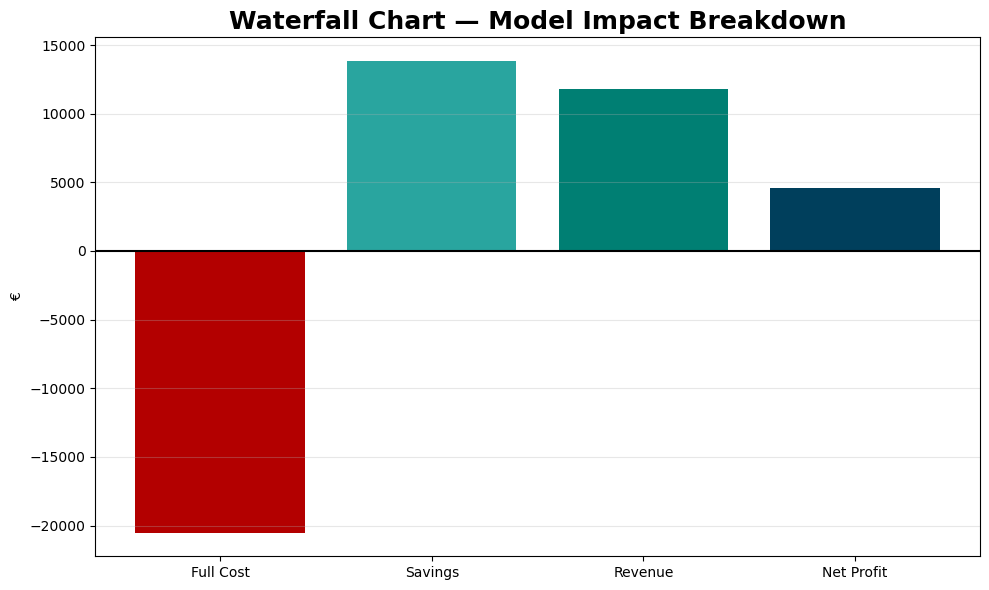

In [576]:
import matplotlib.pyplot as plt

# Compute components
cost_full = len(df_7244) * 0.80
cost_optimal = 8344 * 0.80
savings = cost_full - cost_optimal
revenue_optimal = model_df.loc[model_df["Fraction"] == 0.4, "Revenue_Model"].values[0]  # or use your optimal k revenue
profit_optimal = 4567  # continuous optimum profit

labels = ["Full Cost", "Savings", "Revenue", "Net Profit"]
values = [-cost_full, savings, revenue_optimal, profit_optimal]

colors = ["#b30000", "#29a59f", "#007f73", "#003f5c"]

plt.figure(figsize=(10,6))
plt.bar(labels, values, color=colors)
plt.axhline(0, color="black")
plt.title("Waterfall Chart — Model Impact Breakdown", fontsize=18, weight="bold")
plt.ylabel("€")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


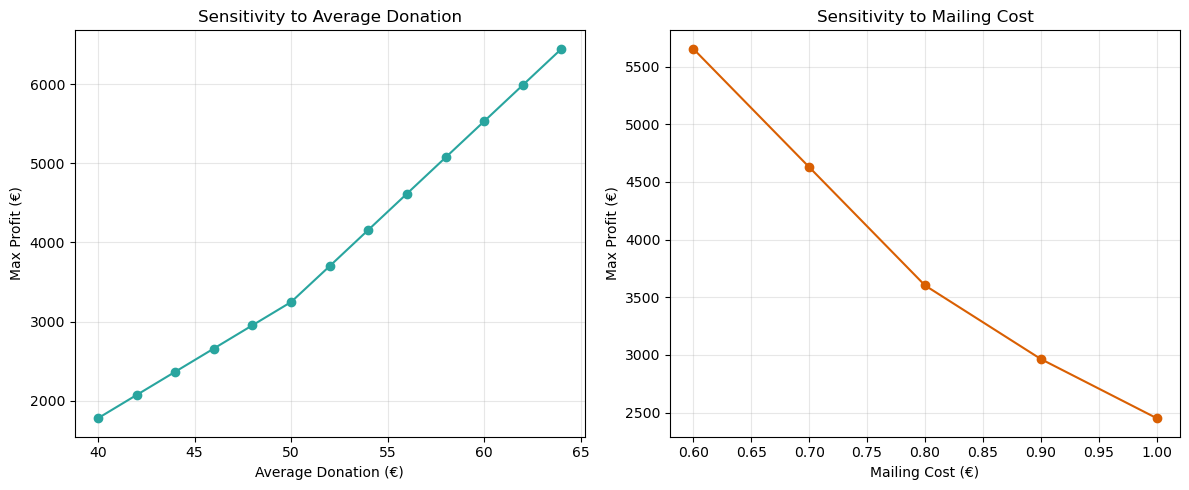

In [577]:
import numpy as np
import matplotlib.pyplot as plt

donation_range = np.arange(40, 66, 2)   # €40 to €64
cost_range = np.arange(0.60, 1.01, 0.10)  # €0.60 to €1.00

profits_donation = []
for d in donation_range:
    revenue = model_df["Num_Customers_Model"] * d
    profit = revenue - model_df["Num_Contacted"] * cost_per_letter
    profits_donation.append(max(profit))

profits_cost = []
for c in cost_range:
    revenue = model_df["Revenue_Model"]
    profit = revenue - model_df["Num_Contacted"] * c
    profits_cost.append(max(profit))

plt.figure(figsize=(12,5))

# Donation sensitivity
plt.subplot(1,2,1)
plt.plot(donation_range, profits_donation, color="#29a59f", marker="o")
plt.title("Sensitivity to Average Donation")
plt.xlabel("Average Donation (€)")
plt.ylabel("Max Profit (€)")
plt.grid(alpha=0.3)

# Cost sensitivity
plt.subplot(1,2,2)
plt.plot(cost_range, profits_cost, color="#d95f02", marker="o")
plt.title("Sensitivity to Mailing Cost")
plt.xlabel("Mailing Cost (€)")
plt.ylabel("Max Profit (€)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Conclusion & Business Impact

This project demonstrates how a data-driven targeting strategy can transform an otherwise unprofitable donor reactivation campaign into a profitable and scalable fundraising initiative.

Using historical donor behavior and demographic data, we developed an end-to-end predictive modeling pipeline to rank inactive donors by their likelihood of making a donation of **€30 or more**. After extensive feature engineering and selection, the final model retained **11 high-value behavioral features** out of more than 70 initial candidates, prioritizing donation history and engagement stability over static metadata.

Among the evaluated algorithms, **CatBoost** delivered the strongest and most stable performance on imbalanced data, achieving an **AUC of 0.7017 on the independent validation campaign (7244)**. Model evaluation using lift and cumulative gains curves confirmed a clear improvement over random targeting. By contacting only the **top 30–40% of scored donors**, the model captures approximately **60–70% of all potential donors**, with lift values close to **2×** in the top deciles.

From a business perspective, the impact is substantial. With a fixed mailing cost of **€0.80 per letter**, random targeting consistently results in negative profit. In contrast, model-based targeting becomes profitable immediately and reaches its optimum at approximately **33% of donors contacted**, generating a total profit of **€4,567** for Campaign 7244. Compared to random selection, this represents an improvement of **€6,467**, along with **€13,800 in cost savings** and a **return on investment of +68%**.

Beyond financial performance, donor profiling reveals a clear “ideal donor” segment: predominantly **female donors aged 60–75**, characterized by stable long-term engagement and consistent giving behavior. These insights support a strategic shift toward focused, high-probability targeting rather than broad, untargeted outreach.

Overall, this project illustrates how predictive analytics can effectively bridge **model performance and real business decision-making**, enabling non-profit organizations to allocate resources more efficiently, reduce waste, and maximize the impact of fundraising campaigns.
